# Dataset - Advanced-MRI-Breast-Lesions
## AI Project SS2026

This project develops a **semi-supervised AI system** for automatic tumor segmentation in breast MRI images.

This notebook covers the first step of the semi-supervised breast cancer segmentation pipeline:

**Dataset Inspection:** Patient folders are scanned and assessed to identify which MRI slices are suitable for further preprocessing and can later be used for AI model training.


In [ ]:
## How to git

# =============================================================================

# 1. Start work with: 
#    git pull

# 2. STARTING THE SESSION (When you open VS Code)
#    Make sure you are on your local development branch before writing any code:
#    $ git checkout test-MRI-data (your branch name - or make a new one)

# 3. LOCAL DEVELOPMENT PHASE
#    Open your Jupyter Notebook, make your code modifications, and test them.
#    Once everything runs smoothly and looks correct, stage your files:
#    $ git add .

# 4. COMMIT THE CHANGES
#    Save your staged changes locally with a clear description of what you did:
#    $ git commit -m "Fix file path automation for Jupyter execution environment"

# 5. PREPARE MAIN BRANCH
#    Switch back to the main branch to prepare for integration:
#    $ git checkout main

# 6. FETCH REMOTE CHANGES
#    Always pull the latest changes from GitHub to prevent merge conflicts:
#    $ git pull origin main

# 7. MERGE WORK INTO MAIN
#    Bring your tested features into your freshly updated local main branch:
#    $ git merge test-MRI-data

# 8. UPDATE GITHUB REMOTE
#    Push the combined, clean state back up to the online GitHub repository:
#    $ git push origin main

# 9. RESET FOR THE NEXT SESSION
#    Switch back to your development branch so you are ready to explore next time:
#    $ git checkout test-MRI-data

# =============================================================================


### Package imports

In [ ]:
# =============================================================================
# Imports - all packages used in this notebook, loaded once here.
# The CUDA PATH line must run before tensorflow is imported.
# =============================================================================
import os                                  # file paths, directory scanning, environment variables
import csv                                 # writing the dataset-survey CSV report
from collections import Counter, defaultdict  # counting series categories, grouping slices by series

import numpy as np                         # array and volume maths (stacking slices, normalisation)
import pandas as pd                        # tabular summaries of the folder survey
import pydicom                             # reading DICOM image and SEG (ROI) files
import cv2                                 # nearest-neighbour resize of ROI masks onto the image grid

import matplotlib.pyplot as plt            # all figures (three-view plots, folder grids)
import matplotlib.gridspec as gridspec     # multi-panel grid layout for the folder explorer

# CUDA runtime on the PATH so TensorFlow can find the GPU (adjust to your CUDA install)
os.environ["PATH"] = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin;" + os.environ["PATH"]
import tensorflow as tf                    # only used here to confirm the GPU is detected before training

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print("Ready!")

### Test load of a single patient to verify the three anatomical views

Test patient: AMBL-002
Loading patient: AMBL-002

Total DICOM files found: 1887

Grouping by series ...

Available series:
  Series                                                         Slices    Z-spacing
  ----------------------------------------------------------------------------------
  0003 – AX Sen Vibrant MASK                                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 1]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 2]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 3]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 4]                        116      2.000mm  (std=0.000)
  0005 – AX Sen Vibrant MultiPhase [Phase 5]                        116      2.000mm  (std=0.000)
  0006 – Ax T2 FSE                                                  116      2.000mm  (std=0.000)
  0007 – Sag T2 FS Le

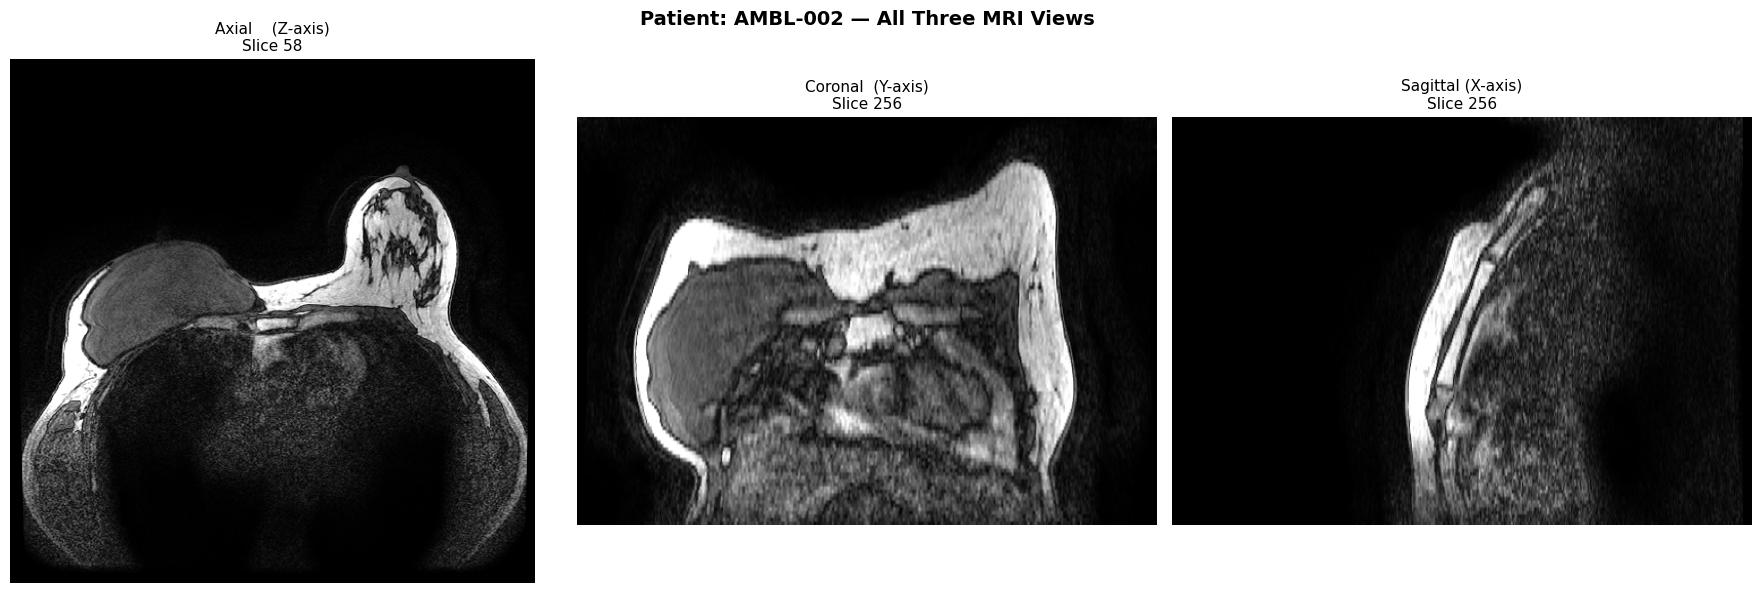


Showing axial overview ...


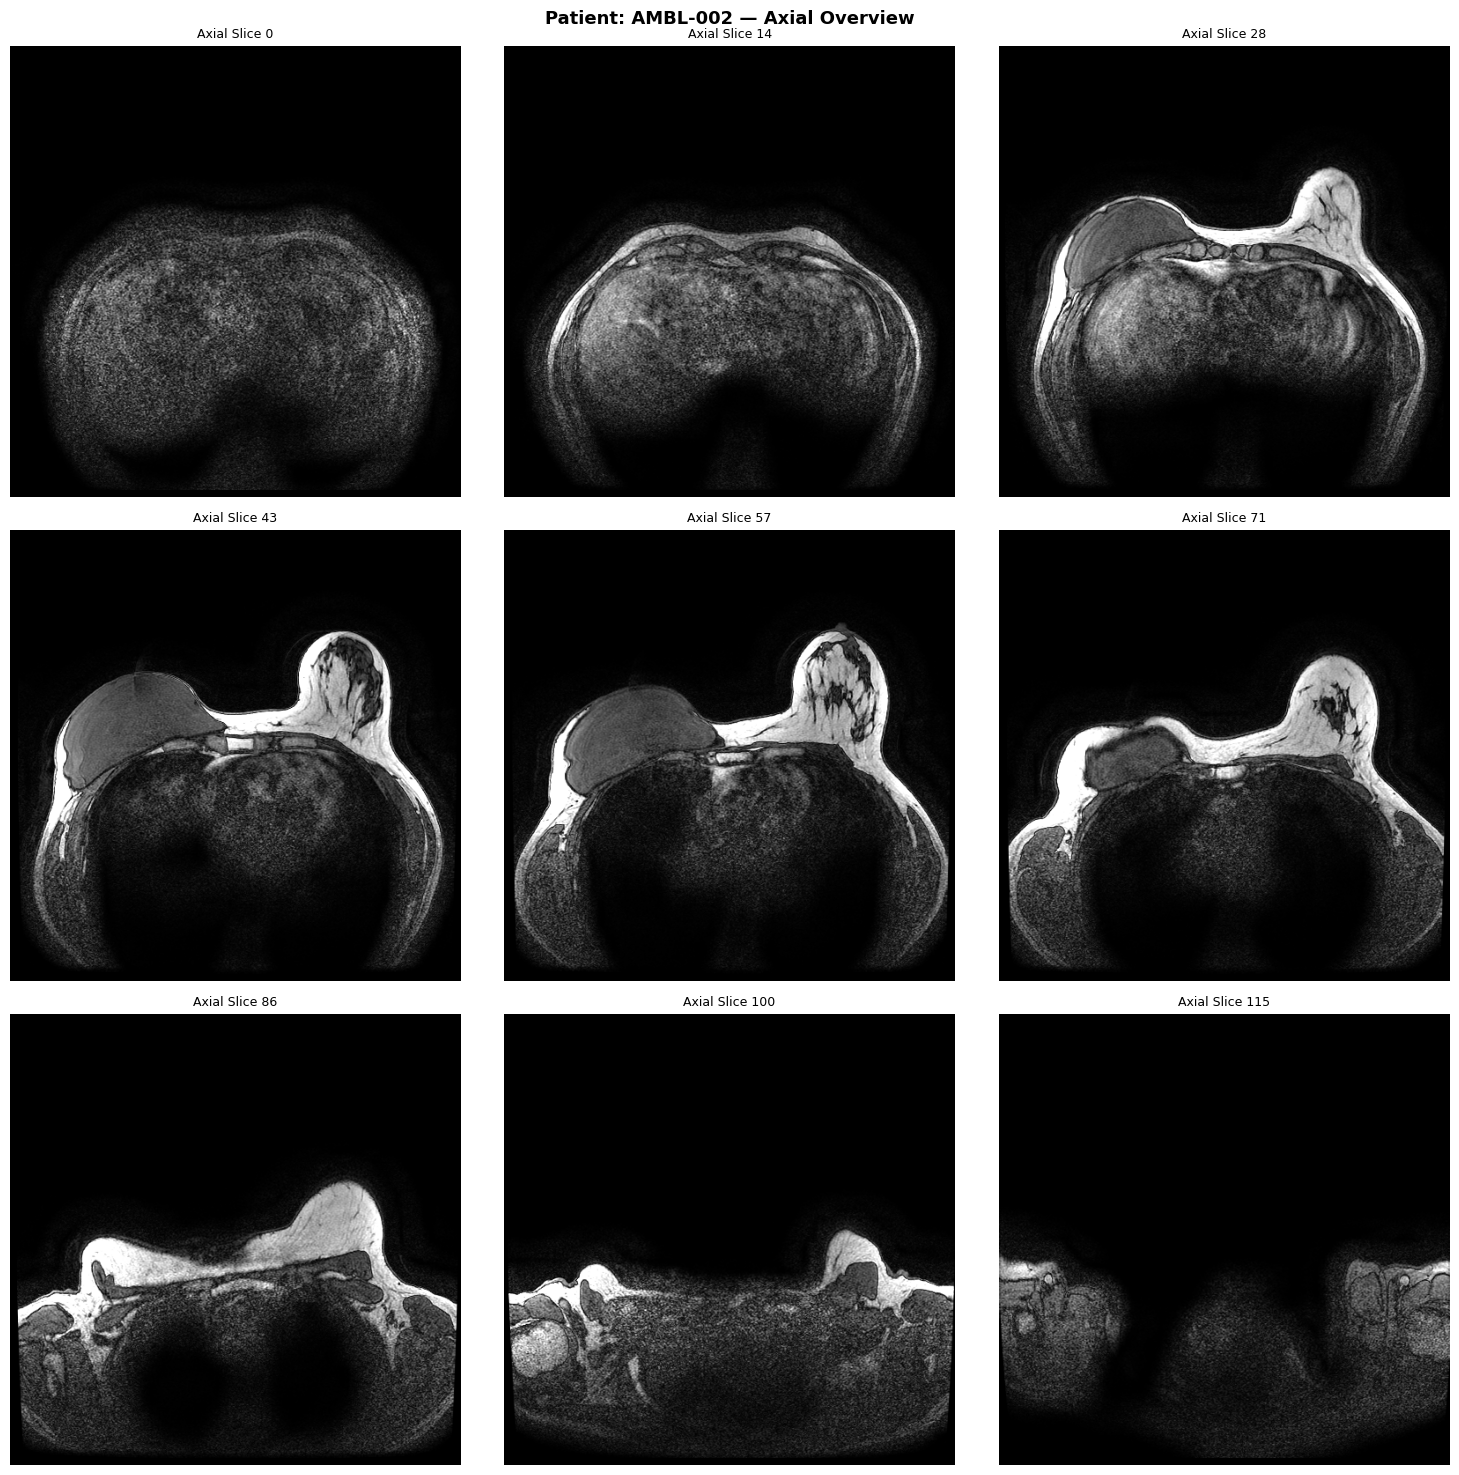


Showing coronal overview ...


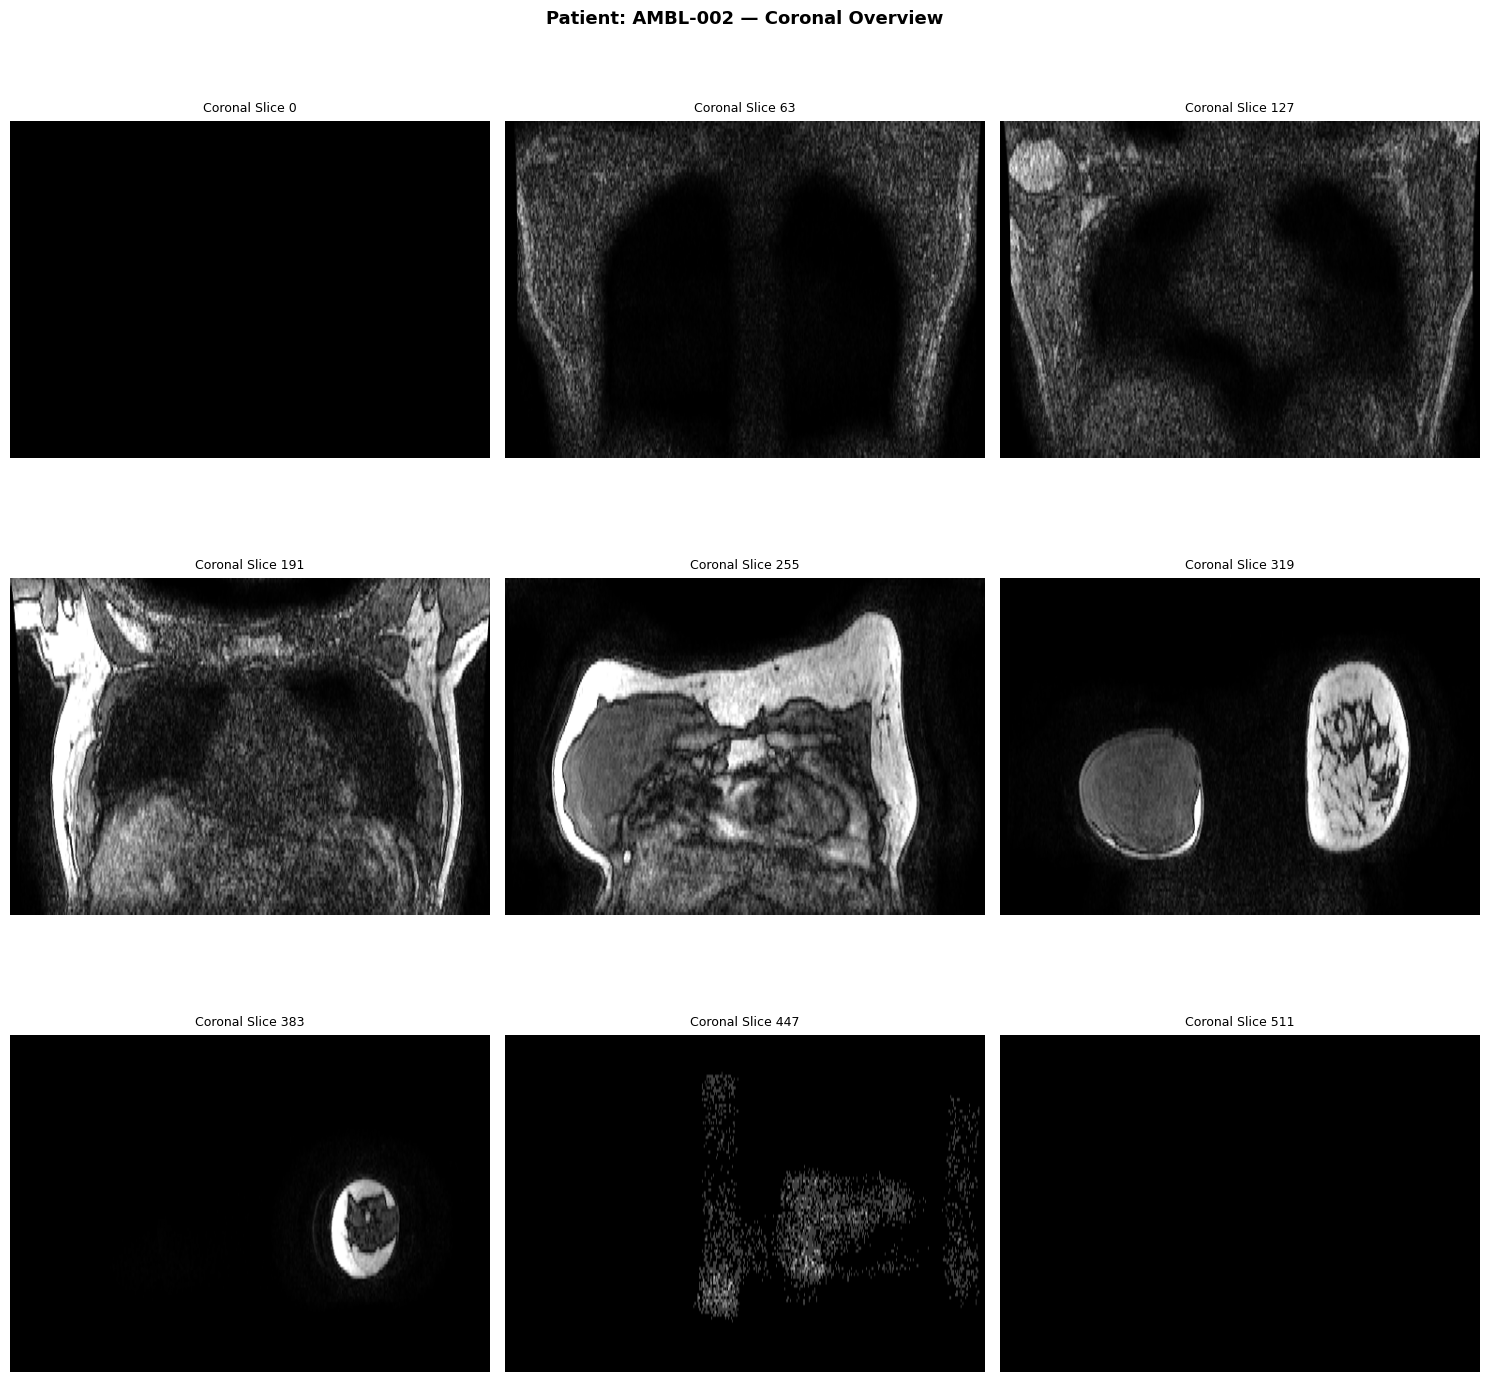


Showing sagittal overview ...


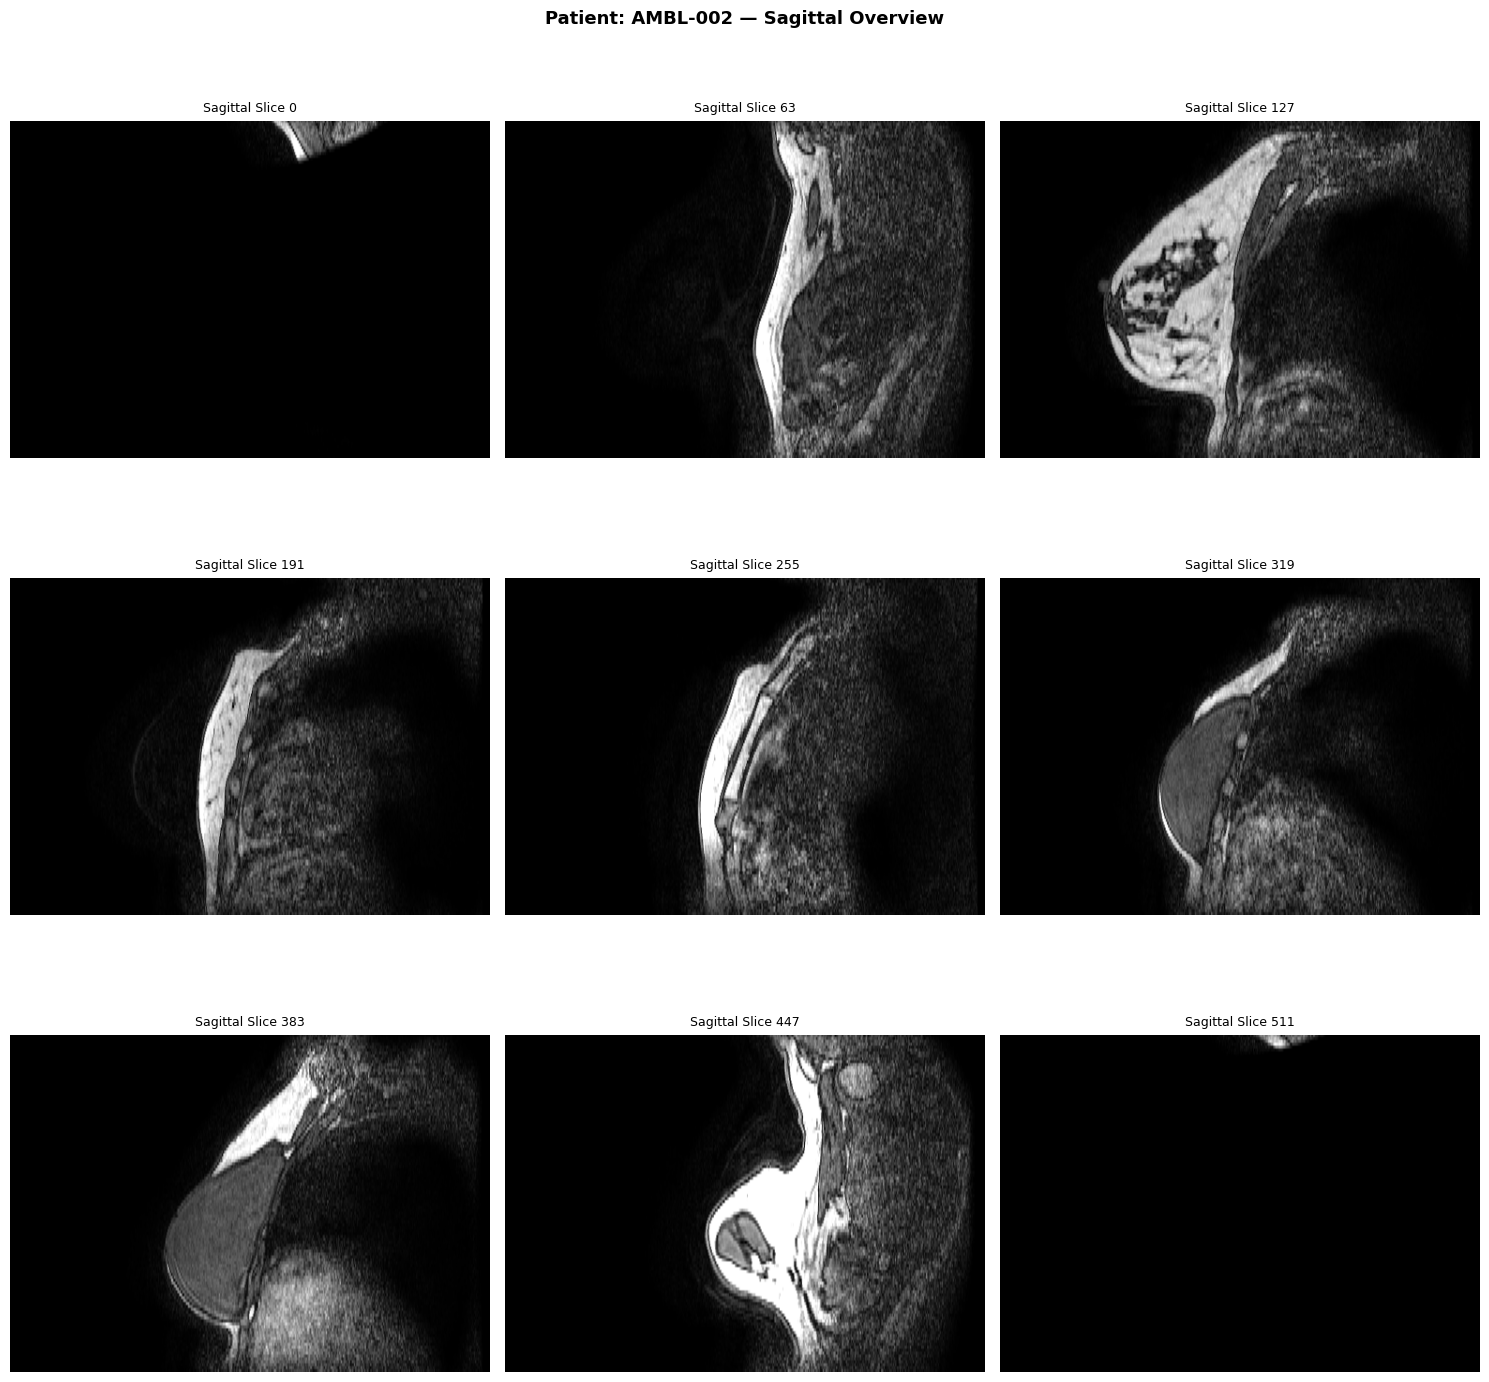

Test complete – no data was saved to disk.


In [ ]:
# =============================================================================
# STEP 1: Test Code - Load MRI Images in All Three Views & Verify

# PATHS & CONFIGURATION
# =============================================================================

# Get the current working directory of the Jupyter Notebook
SCRIPT_DIR = os.getcwd()

# 1. External Large Data Path (Keep manual as the 600GB SSD moves between people - as of now, until data is fully processed)
DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

EXCEL_PATH   = os.path.abspath(os.path.join(SCRIPT_DIR, "..", "Advanced-MRI-Breast-Lesions-DA-Clinical-Sep2024.xlsx"))
CACHE_DIR    = os.path.abspath(os.path.join(SCRIPT_DIR, "..", "data", "processed")) # later for saving the data - of no use right now
os.makedirs(CACHE_DIR, exist_ok=True)

#----------------------------------------------------------------------------------------

# Target search query for selecting the post-contrast axial sequence.
# Modified from "+C" to "C" to perfectly match specific folder namings.
# This was defined to later only show plots of this folder - if wanted can be changed to look at different images from the patient
TARGET_SERIES = "AX Sen Vibrant C"

# Read all patient directories from the root folder and sort them alphabetically
all_patients = sorted(os.listdir(DICOM_FOLDER))
TEST_PATIENT = all_patients[1]  # e.g. [0] selects the first patient in the folder (AMBL-001) for pipeline verification, can be changed if you want to look at different patients
print(f"Test patient: {TEST_PATIENT}")


# =============================================================================
# STEP 1: FIND AND GROUP DICOM FILES BY SCANNING SERIES
# =============================================================================

def find_image_dicoms(patient_id, dicom_folder):
    """
    Walks the directory tree of one patient and collects all valid MRI image slices.
    Non-image folders such as annotations (ROI) or motion-correction maps (TRAM) are filtered out.
    """
    # Build absolute path to the targeted patient directory
    ppath = os.path.join(dicom_folder, patient_id)
    
    # Identify subdirectories inside the patient folder
    subs  = [os.path.join(ppath, d) for d in os.listdir(ppath)
             if os.path.isdir(os.path.join(ppath, d))]
    if not subs:
        return []

    # The TCIA manifest wraps each patient in a single subfolder
    patient_subfolder = subs[0]
    image_paths = []

    # Loop through individual scan sequence directories
    for d in os.listdir(patient_subfolder):
        # Ignore structural segmentations (ROI) or specialized map files (TRAM) -> for ROI this is only for now
        # But TRAM data will generally be fully ignored - is of no use for us
        if d.upper().startswith(("ROI", "TRAM")):
            continue
            
        sub = os.path.join(patient_subfolder, d)
        if os.path.isdir(sub):
            # Collect paths of files ending with .dcm (Standard DICOM format)
            image_paths += [
                os.path.join(sub, f) for f in os.listdir(sub)
                if f.lower().endswith(".dcm")
            ]
    return image_paths


def group_by_series(image_paths):
    """
    Reads DICOM metadata headers to group individual slice files into coherent 3D volumes.
    MultiPhase series are detected and their temporal phases are split into separate keys.
    """
    # defaultdict automatically creates an empty list when encountering a new dictionary key
    series_dict = defaultdict(list)

    for path in image_paths:
        # Read metadata only (stop before the pixel array) to keep the scan fast
        ds = pydicom.dcmread(path, stop_before_pixels=True)
        
        # A slice needs a physical 3D position to be stacked into a volume
        if not hasattr(ds, "ImagePositionPatient"):
            continue

        # Extract the absolute Z-axis physical coordinate of the slice
        z          = float(ds.ImagePositionPatient[2])
        series_num = getattr(ds, "SeriesNumber", 0)
        series_desc= getattr(ds, "SeriesDescription", "Unknown")

        # MultiPhase sequences hold several timepoints under one description.
        # Specific DICOM tags separate these into distinct volumes.
        temporal   = getattr(ds, "TemporalPositionIdentifier", None)
        acq_num    = getattr(ds, "AcquisitionNumber", None)

        if temporal is not None:
            key = f"{series_num:04d} – {series_desc} [Phase {temporal}]"
        elif acq_num is not None and "MultiPhase" in series_desc:
            key = f"{series_num:04d} – {series_desc} [Acq {acq_num}]"
        else:
            key = f"{series_num:04d} – {series_desc}"

        # Store (Z-coordinate, file path); Z is used for sorting
        series_dict[key].append((z, path))

    # Sort the slices of every series by Z, so stacking yields a spatially continuous volume.
    for key in series_dict:
        series_dict[key].sort(key=lambda x: x[0])

    return series_dict


def select_series(series_dict, target_desc=None):
    """
    Evaluates the available series and picks the most suitable one for 3D processing.
    Filters by keyword and uses a variance check on the Z-spacing to reject series with
    irregular slice distributions.
    """
    print("\nAvailable series:")
    print(f"  {'Series':<60} {'Slices':>8}   {'Z-spacing':>10}")
    print("  " + "-" * 82)

    candidates = []

    for key, slices in sorted(series_dict.items()):
        z_vals = [s[0] for s in slices]

        # Measure spacing consistency from the gaps between consecutive slices
        if len(z_vals) > 1:
            diffs      = [abs(z_vals[i+1] - z_vals[i]) for i in range(len(z_vals)-1)]
            z_med      = float(np.median(diffs)) # typical slice thickness
            z_std      = float(np.std(diffs))    # variation in thickness across the stack
            uniformity= z_std / (z_med + 1e-6)  # near 0 means evenly spaced slices
        else:
            z_med, z_std, uniformity = 0, 0, 999

        print(f"  {key:<60} {len(slices):>8}   {z_med:>8.3f}mm  (std={z_std:.3f})")

        candidates.append({
            "key":        key,
            "slices":     slices,
            "count":      len(slices),
            "z_spacing":  z_med,
            "uniformity": uniformity,
        })

    # Strategy 1: match the requested target keyword
    if target_desc:
        matches = [c for c in candidates if target_desc.lower() in c["key"].lower()]
        if matches:
            # If several phases match, take the one with the most uniform spacing
            best = min(matches, key=lambda c: c["uniformity"])
            print(f"\n  → Selected (target match): '{best['key']}' "
                  f"({best['count']} slices, z={best['z_spacing']:.3f}mm)")
            return best["key"], best["slices"]

    # Strategy 2 (fallback): take the largest volume with uniform slice spacing
    uniform = [c for c in candidates if c["uniformity"] < 0.1 and c["count"] > 50]
    if uniform:
        best = max(uniform, key=lambda c: c["count"])
    else:
        best = max(candidates, key=lambda c: c["count"])

    print(f"\n  → Selected (fallback): '{best['key']}' "
          f"({best['count']} slices, z={best['z_spacing']:.3f}mm)")
    return best["key"], best["slices"]


# =============================================================================
# STEP 2: LOAD TENSOR VOLUME AND INTENSITY NORMALIZATION
# =============================================================================

def load_volume_from_series(series_slices):
    """
    Loads the raw pixel arrays into one 3D NumPy array.
    Normalises contrast by percentile clipping and computes the physical voxel spacing.
    """
    z_positions = [s[0] for s in series_slices]
    paths       = [s[1] for s in series_slices]

    # Read the first slice metadata to obtain pixel spacing
    ds0         = pydicom.dcmread(paths[0])
    row_spacing = float(ds0.PixelSpacing[0]) if hasattr(ds0, "PixelSpacing") else 1.0
    col_spacing = float(ds0.PixelSpacing[1]) if hasattr(ds0, "PixelSpacing") else 1.0

    # Estimate physical slice thickness (Z-spacing) from the median of Z differences
    if len(z_positions) > 1:
        diffs     = [abs(z_positions[i+1] - z_positions[i])
                     for i in range(len(z_positions) - 1)]
        z_spacing = float(np.median(diffs))
    else:
        z_spacing = 1.0

    # Guard against invalid or zero spacing by falling back to 1.0
    z_spacing   = z_spacing   if (np.isfinite(z_spacing)   and z_spacing   > 0) else 1.0
    row_spacing = row_spacing if (np.isfinite(row_spacing) and row_spacing > 0) else 1.0
    col_spacing = col_spacing if (np.isfinite(col_spacing) and col_spacing > 0) else 1.0

    print(f"\n  Slices loaded:    {len(paths)}")
    print(f"  Z-spacing:        {z_spacing:.4f} mm")
    print(f"  Row spacing:      {row_spacing:.4f} mm")
    print(f"  Col spacing:      {col_spacing:.4f} mm")
    print(f"  Image size:       {ds0.pixel_array.shape}")

    # Load the full voxel matrix as 32-bit float
    pixel_arrays = [pydicom.dcmread(p).pixel_array.astype(np.float32) for p in paths]
    volume       = np.stack(pixel_arrays, axis=0) # shape (Z, H, W)

    # Intensity normalisation:
    # Bright artefacts (e.g. fat) stretch the histogram, so the top and bottom 1% are
    # clipped to stabilise the contrast window before scaling to [0, 1].
    p1, p99 = np.percentile(volume, 1), np.percentile(volume, 99)
    volume  = np.clip(volume, p1, p99)
    volume  = (volume - p1) / (p99 - p1 + 1e-6) # epsilon guards against division by zero

    return volume, (z_spacing, row_spacing, col_spacing)


# =============================================================================
# STEP 3: AXIAL, CORONAL, AND SAGITTAL VIEW ALIGNMENT (MATCHING 3D SLICER)
# =============================================================================

def safe_aspect(num, den):
    """Avoids division errors when a spacing value is zero or invalid."""
    if den == 0 or not np.isfinite(num / den):
        return 1.0
    r = num / den
    return r if r > 0 else 1.0


def get_three_views(volume, slice_idx=None):
    """
    Slices the 3D volume along its three principal axes.
    Flips are applied so the orientation matches 3D Slicer (prone breast MRI positioning):
    - np.flipud keeps the superior body direction at the top,
    - np.fliplr swaps left/right to mirror the 3D Slicer layout.
    """
    Z, H, W = volume.shape
    # Use the central slice of the volume if none is specified
    z_mid = Z // 2 if slice_idx is None else min(slice_idx, Z - 1)
    y_mid = H // 2
    x_mid = W // 2

    # 1. Axial view: horizontal slice, mirrored vertically and horizontally to match 3D Slicer
    axial = np.fliplr(np.flipud(volume[z_mid, :, :]))

    # 2. Coronal view: front-to-back slice, mirrored vertically and horizontally
    coronal = np.fliplr(np.flipud(volume[:, y_mid, :]))

    # 3. Sagittal view: side-to-side slice, using the same flip logic
    sagittal = np.fliplr(np.flipud(volume[:, :, x_mid]))

    return {
        "axial":    (axial,    z_mid, "Axial    (Z-axis)"),
        "coronal":  (coronal,  y_mid, "Coronal  (Y-axis)"),
        "sagittal": (sagittal, x_mid, "Sagittal (X-axis)"),
    }


# =============================================================================
# STEP 4: MATPLOTLIB RENDER ENGINE
# =============================================================================

def visualize_three_views(views, patient_id, spacing):
    """Plots the three principal cross-sections side by side."""
    z_sp, r_sp, c_sp = spacing
    
    # Correct the aspect ratio for anisotropic voxels (slice thickness differs from in-plane spacing)
    aspect_ratios = {
        "axial":    safe_aspect(r_sp, c_sp),
        "coronal":  safe_aspect(z_sp, c_sp),
        "sagittal": safe_aspect(z_sp, r_sp),
    }

    print(f"  Aspect ratios → axial: {aspect_ratios['axial']:.3f} | "
          f"coronal: {aspect_ratios['coronal']:.3f} | "
          f"sagittal: {aspect_ratios['sagittal']:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Patient: {patient_id} — All Three MRI Views",
                 fontsize=14, fontweight="bold")

    for ax, (key, (img, idx, title)) in zip(axes, views.items()):
        ax.imshow(img, cmap="gray", aspect=aspect_ratios[key])
        ax.set_title(f"{title}\nSlice {idx}", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_multiple_slices(volume, spacing, view="axial", n_slices=9):
    """
    Generates a 3x3 grid of evenly spaced slices.
    Useful for inspecting the full lesion extent or spotting spatial artefacts.
    """
    Z, H, W          = volume.shape
    z_sp, r_sp, c_sp = spacing

    # Pick evenly spaced slice indices along the chosen axis
    if view == "axial":
        indices = np.linspace(0, Z - 1, n_slices, dtype=int)
        # Flip each slice to match the 3D Slicer left/right layout
        imgs    = [np.fliplr(np.flipud(volume[i, :, :])) for i in indices]
        aspect  = safe_aspect(r_sp, c_sp)
        label   = "Axial Slice"
    elif view == "coronal":
        indices = np.linspace(0, H - 1, n_slices, dtype=int)
        # Flip each slice to match the 3D Slicer left/right layout
        imgs    = [np.fliplr(np.flipud(volume[:, i, :])) for i in indices]
        aspect  = safe_aspect(z_sp, c_sp)
        label   = "Coronal Slice"
    elif view == "sagittal":
        indices = np.linspace(0, W - 1, n_slices, dtype=int)
        imgs    = [np.fliplr(np.flipud(volume[:, :, i])) for i in indices]
        aspect  = safe_aspect(z_sp, r_sp)
        label   = "Sagittal Slice"

    cols  = 3
    rows  = (n_slices + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axes  = axes.flatten()

    for i, (img, idx) in enumerate(zip(imgs, indices)):
        axes[i].imshow(img, cmap="gray", aspect=aspect)
        axes[i].set_title(f"{label} {idx}", fontsize=9)
        axes[i].axis("off")

    # Hide any unused subplot cells in the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Patient: {TEST_PATIENT} — {view.capitalize()} Overview",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN EXECUTION ENTRY POINT
# =============================================================================
if __name__ == "__main__":
    print("=" * 60)
    print(f"Loading patient: {TEST_PATIENT}")
    print("=" * 60)

    # 1. Collect the image DICOM paths for the test patient
    image_paths = find_image_dicoms(TEST_PATIENT, DICOM_FOLDER)
    print(f"\nTotal DICOM files found: {len(image_paths)}")

    if len(image_paths) == 0:
        print("ERROR: No DICOM files found. Please check the path.")
    else:
        # 2. Group the loose slice files into sorted series
        print("\nGrouping by series ...")
        series_dict = group_by_series(image_paths)

        # 3. Evaluate the series and select the best one
        best_key, best_series = select_series(series_dict, target_desc=TARGET_SERIES)

        # 4. Build the normalised 3D volume and read its voxel spacing
        print("\nLoading volume ...")
        volume, spacing = load_volume_from_series(best_series)
        print(f"\nVolume shape: {volume.shape}  (Z, H, W)")
        print(f"Value range:  [{volume.min():.3f}, {volume.max():.3f}]")

        # 5. Extract the three views, oriented to match 3D Slicer
        views = get_three_views(volume)

        # 6. Render the plots
        print("\nShowing all three views ...")
        visualize_three_views(views, TEST_PATIENT, spacing)

        print("\nShowing axial overview ...")
        visualize_multiple_slices(volume, spacing, view="axial", n_slices=9)

        print("\nShowing coronal overview ...")
        visualize_multiple_slices(volume, spacing, view="coronal", n_slices=9)

        print("\nShowing sagittal overview ...")
        visualize_multiple_slices(volume, spacing, view="sagittal", n_slices=9)

        print("Test complete – no data was saved to disk.")


### DICOM folder explorer (single patient)

**Purpose:** inspect which series folders exist for one patient, how many slices each contains, and what the most informative slice of each looks like.

**Output:** a console table and a PNG grid saved to disk.

**Note:** TRAM folders are always skipped (motion-correction maps, not used for training).

Patient: AMBL-001

  Folder name                                              DICOM files            Type
  -------------------------------------------------------------------------------------
  10.000000-AX Sen Vibrant C-31889                                 116    MRI Sequence
  1000.000000-Registered AX Sen Vibrant C-73826                    116      Registered
  3.000000-AX Sen Vibrant MASK-29193                               116       Body mask
  5.000000-AX Sen Vibrant MultiPhase-92144                         580      MultiPhase
  500.000000-ROI-38451                                               1    ROI (tumour)
  500.000000-Registered AX Sen Vibrant MultiPhase-85715            580      Registered
  6.000000-Ax T2 FSE-57307                                         116              T2
  600.000000-Registered Ax T2 FSE-08519                            116      Registered
  7.000000-AX Sen Vibrant C-20369                                  116    MRI Sequence
  700.000000-Registered

C:\Users\atame\AppData\Local\Temp\ipykernel_13156\3135411913.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


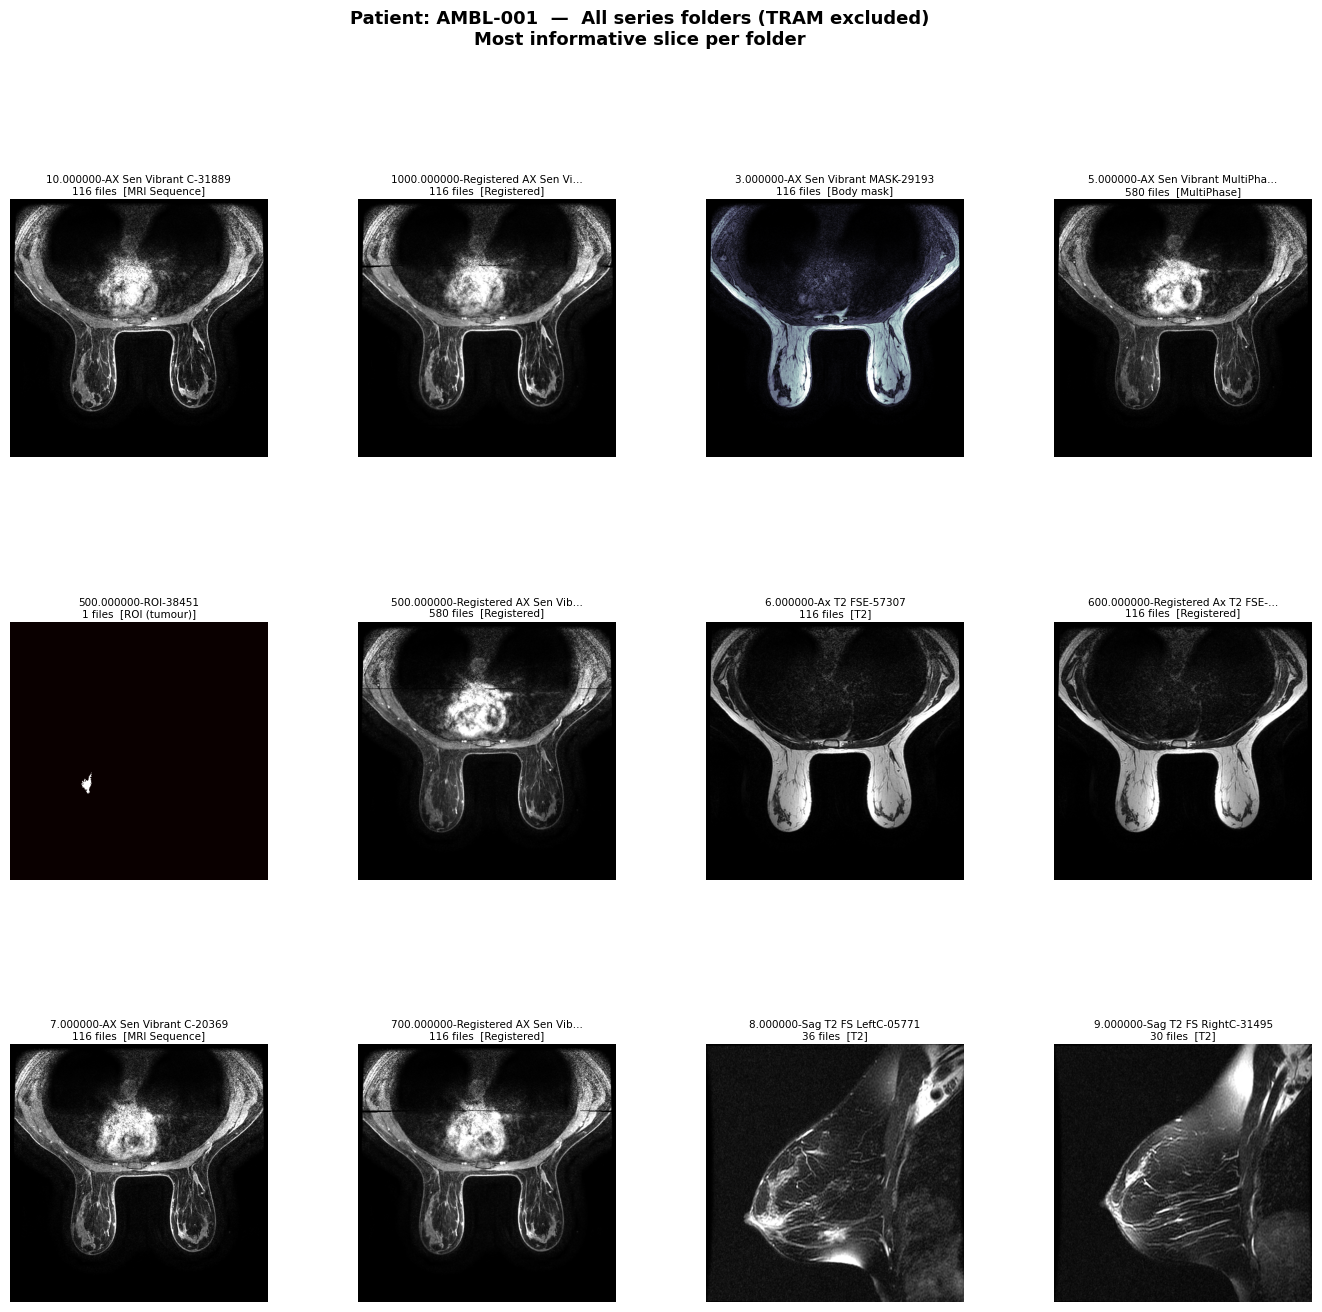

Grid saved to: patient_folder_overview.png

PIPELINE RELEVANCE SUMMARY
  10.000000-AX Sen Vibrant C-31889                      →  Raw post-contrast axial  (fallback if no registered version)
  1000.000000-Registered AX Sen Vibrant C-73826         →  Registered post-contrast axial  (preferred input sequence)
  3.000000-AX Sen Vibrant MASK-29193                    →  Background mask  (can be used to crop breast region)
  5.000000-AX Sen Vibrant MultiPhase-92144              →  Multi-temporal sequence  (pre/post contrast phases)
  500.000000-ROI-38451                                  ✓  Ground-truth tumour mask  →  supervised training target
  500.000000-Registered AX Sen Vibrant MultiPhase-85715  →  Registered post-contrast axial  (preferred input sequence)
  6.000000-Ax T2 FSE-57307                              →  T2 sequence  (different contrast, optional modality)
  600.000000-Registered Ax T2 FSE-08519                 →  T2 sequence  (different contrast, optional modality)
  7.000000

In [ ]:
# =============================================================================
# DICOM Folder Explorer
# Purpose : Understand what series folders exist for a given patient,
#           how many slices each contains, and what the middle slice looks like.
# Output  : Console table  +  PNG grid saved to disk
#
# Key behaviours:
#   - TRAM folders are always excluded (matched anywhere in the name, not just
#     at the start - folder names often begin with a numeric prefix)
#   - ROI / mask folders that pack all frames into one file are handled by
#     scanning all frames and showing the one with the most active pixels
#     (the "most informative" frame) rather than blindly taking the middle
#   - Body masks (large white regions) are shown as-is so you can distinguish
#     them visually from tumour ROIs
# =============================================================================


# =============================================================================
# CONFIGURATION
# =============================================================================

DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

# Pick any patient by index (0 = first alphabetically) or set a specific ID.
all_patients = sorted(os.listdir(DICOM_FOLDER))
PATIENT_ID   = all_patients[0]

print(f"Patient: {PATIENT_ID}\n")


# =============================================================================
# STEP 1 - Discover series folders and count DICOM files
# =============================================================================
# Folder hierarchy:
#   DICOM_FOLDER / <PatientID> / <ManifestSubfolder> / <SeriesFolder> / *.dcm

patient_path = os.path.join(DICOM_FOLDER, PATIENT_ID)

manifest_level = [
    d for d in os.listdir(patient_path)
    if os.path.isdir(os.path.join(patient_path, d))
]
if not manifest_level:
    raise FileNotFoundError(f"No subfolder found under {patient_path}")

patient_subfolder = os.path.join(patient_path, manifest_level[0])

# Exclude TRAM folders - matched anywhere in the name because folder names
# are prefixed with a series number (e.g. "5000.000000-TRAM-23432").
# Using "TRAM" in name catches all variants reliably.
series_dirs = sorted([
    d for d in os.listdir(patient_subfolder)
    if os.path.isdir(os.path.join(patient_subfolder, d))
    and "TRAM" not in d.upper()
])


def classify_folder(folder_name):
    """
    Returns a short category string based on keywords in the folder name.
    Used only for display and pipeline guidance — not for data filtering.
    """
    name = folder_name.upper()
    if "ROI" in name:
        return "ROI (tumour)"
    elif "MASK" in name:
        return "Body mask"
    elif "REGISTERED" in name:
        return "Registered"
    elif "MULTIPHASE" in name:
        return "MultiPhase"
    elif "T2" in name:
        return "T2"
    elif "AX" in name or "SAG" in name:
        return "MRI Sequence"
    else:
        return "Other"

# -----------------------------------------------------------------------------
# Console table 
print(f"  {'Folder name':<55} {'DICOM files':>12}  {'Type':>14}")
print("  " + "-" * 85)

folder_info = []

for dirname in series_dirs:
    full_path = os.path.join(patient_subfolder, dirname)
    dcm_files = sorted([
        f for f in os.listdir(full_path)
        if f.lower().endswith(".dcm")
    ])
    folder_type = classify_folder(dirname)

    print(f"  {dirname:<55} {len(dcm_files):>12}  {folder_type:>14}")

    folder_info.append({
        "name"    : dirname,
        "path"    : full_path,
        "n_slices": len(dcm_files),
        "files"   : dcm_files,
        "type"    : folder_type,
    })

total_dcm = sum(f["n_slices"] for f in folder_info)
print(f"\n  Total: {len(folder_info)} folders, {total_dcm} DICOM files (TRAM excluded)\n")


# =============================================================================
# STEP 2 - Load the most informative slice from each folder
# =============================================================================
# Three scenarios we need to handle:
#
#   A) Regular image folder  - one .dcm file per slice -> shape (H, W)
#      Strategy: take the middle file by index.
#
#   B) Packed multi-frame file - one .dcm file holds all slices -> shape (N, H, W)
#      This happens for MultiPhase and sometimes Registered series.
#      Strategy: take the middle frame along axis 0.
#
#   C) Packed ROI / segmentation file - shape (N, H, W), mostly empty frames
#      Taking the middle frame often lands on a blank slice (no tumour there).
#      Strategy: scan ALL frames and pick the one with the highest pixel sum
#      (i.e. the frame where the annotated tumour region is largest).

def load_best_slice(folder_dict):
    """
    Returns a 2D float32 array (H, W) representing the most informative
    slice in the folder, guaranteed to be 2D for imshow.

    For ROI folders, "most informative" means the frame with the most
    non-zero pixels — avoiding the common problem of showing a blank frame.
    For all other folders the middle slice / frame is used.

    Returns None if no files exist or all reads fail.
    """
    files = folder_dict["files"]
    if not files:
        return None

    is_roi = folder_dict["type"] == "ROI (tumour)"

    # -----------------------------------------------------------------------------
    # Case A / B: non-ROI folders 
    if not is_roi:
        mid_path = os.path.join(folder_dict["path"], files[len(files) // 2])
        try:
            arr = pydicom.dcmread(mid_path).pixel_array.astype(np.float32)
        except Exception as e:
            print(f"  Could not read {mid_path}: {e}")
            return None

        # Packed multi-frame: extract the middle frame
        if arr.ndim == 3:
            arr = arr[arr.shape[0] // 2]

        # Fallback for any unexpected extra dimension
        if arr.ndim != 2:
            arr = arr[..., 0]

        # Percentile normalisation: suppresses bright fat / air artefacts
        p1, p99 = np.percentile(arr, 1), np.percentile(arr, 99)
        if p99 - p1 < 1e-6:
            return arr
        return np.clip((arr - p1) / (p99 - p1), 0, 1)

    # -----------------------------------------------------------------------------
    # Case C: ROI / tumour segmentation folder 
    # Read every .dcm file (usually just one packed file, occasionally several)
    # and collect all frames into a list, then pick the frame with the most
    # active (non-zero) pixels so we always display visible annotation.
    all_frames = []

    for fname in files:
        fpath = os.path.join(folder_dict["path"], fname)
        try:
            arr = pydicom.dcmread(fpath).pixel_array.astype(np.float32)
        except Exception as e:
            print(f"  Skipping unreadable file {fname}: {e}")
            continue

        # Flatten packed multi-frame files into individual 2D arrays
        if arr.ndim == 3:
            for k in range(arr.shape[0]):
                all_frames.append(arr[k])
        elif arr.ndim == 2:
            all_frames.append(arr)

    if not all_frames:
        return None

    # Score each frame by total pixel sum and pick the highest-scoring one.
    # For binary segmentation masks this equals the number of annotated pixels.
    best_frame = max(all_frames, key=lambda f: f.sum())

    # Binarise: any pixel > 0 belongs to the annotated tumour region
    return (best_frame > 0).astype(np.float32)


# =============================================================================
# STEP 3 - Grid plot: one panel per folder
# =============================================================================
# Layout  : 4 columns, as many rows as needed.
# Colormaps: "hot"  for ROI tumour masks  (bright region = tumour)
#            "bone" for body masks        (distinguishable from tumour ROIs)
#            "gray" for all MRI sequences

COLS = 4
ROWS = (len(folder_info) + COLS - 1) // COLS

fig = plt.figure(figsize=(COLS * 4.2, ROWS * 4.8))
fig.suptitle(
    f"Patient: {PATIENT_ID}  —  All series folders (TRAM excluded)\n"
    f"Most informative slice per folder",
    fontsize=13, fontweight="bold", y=1.01,
)

gs = gridspec.GridSpec(ROWS, COLS, figure=fig, hspace=0.6, wspace=0.35)

for i, info in enumerate(folder_info):
    ax  = fig.add_subplot(gs[i // COLS, i % COLS])
    img = load_best_slice(info)

    if img is None:
        ax.text(0.5, 0.5, "No image", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="gray")
        ax.axis("off")
        continue

    if info["type"] == "ROI (tumour)":
        cmap = "hot"
    elif info["type"] == "Body mask":
        cmap = "bone"
    else:
        cmap = "gray"

    ax.imshow(img, cmap=cmap, origin="upper")

    short_name = info["name"] if len(info["name"]) <= 34 else info["name"][:32] + "…"
    ax.set_title(
        f"{short_name}\n{info['n_slices']} files  [{info['type']}]",
        fontsize=7.5, pad=4,
    )
    ax.axis("off")

# Hide leftover empty panels
for j in range(i + 1, ROWS * COLS):
    fig.add_subplot(gs[j // COLS, j % COLS]).axis("off")

plt.tight_layout()
output_path = "patient_folder_overview.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Grid saved to: {output_path}")


# =============================================================================
# STEP 4 - Pipeline relevance summary
# =============================================================================

print("\n" + "=" * 70)
print("PIPELINE RELEVANCE SUMMARY")
print("=" * 70)

for info in folder_info:
    name = info["name"].upper()
    t    = info["type"]

    if t == "ROI (tumour)":
        hint = "Okay -  Ground-truth tumour mask  →  supervised training target"
    elif t == "Body mask":
        hint = "->  Background mask  (can be used to crop breast region)"
    elif "REGISTERED" in name and "AX SEN VIBRANT" in name:
        hint = "->  Registered post-contrast axial  (preferred input sequence)"
    elif "AX SEN VIBRANT C" in name and "REGISTERED" not in name:
        hint = "->  Raw post-contrast axial  (fallback if no registered version)"
    elif "MULTIPHASE" in name:
        hint = "->  Multi-temporal sequence  (pre/post contrast phases)"
    elif "T2" in name:
        hint = "->  T2 sequence  (different contrast, optional modality)"
    elif "SAG" in name:
        hint = "->  Sagittal view  (not used in axial pipeline)"
    else:
        hint = "   –  not directly relevant"

    print(f"  {info['name']:<52}  {hint}")

### Dataset-wide folder-structure survey

**Purpose:** scan all patients and summarise which series types exist, how often they appear, and flag structural anomalies.

**Output:** a console summary and a CSV report saved to disk.

**Runtime:** only folder names and file counts are read (no pixel data), so this completes in a few minutes even for the full dataset on an external drive.

In [ ]:
# =============================================================================
# Dataset-wide Folder Structure Survey
# Purpose : Scan all ~620 patients and summarise which series types exist,
#           how frequently they appear, and flag structural anomalies.
# Output  : Console summary  +  CSV report saved to disk
# Runtime : Reads only folder names and file counts - no pixel data is loaded,
#           so this runs in a few minutes even over a large dataset on USB.
# =============================================================================

# =============================================================================
# CONFIGURATION
# =============================================================================

DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

# Output CSV path - saved next to wherever you run this notebook
OUTPUT_CSV = "dataset_survey.csv"

# =============================================================================
# HELPER - classify a series folder name into a short category label
# =============================================================================
# Same logic as the single-patient explorer, kept consistent so categories
# match across both scripts.

def classify_folder(folder_name):
    """
    Returns a short category string based on keywords in the folder name.
    Order matters: more specific checks come first.
    """
    name = folder_name.upper()

    if "TRAM" in name:
        return "TRAM"                          # always skip in pipeline
    elif "ROI" in name:
        return "ROI (tumour)"                  # ground-truth tumour mask
    elif "MASK" in name:
        return "Body mask"                     # background / body outline mask
    elif "REGISTERED" in name and "MULTIPHASE" in name:
        return "Registered MultiPhase"
    elif "REGISTERED" in name and "T2" in name:
        return "Registered T2"
    elif "REGISTERED" in name and "AX" in name:
        return "Registered AX Vibrant"         # best candidate for training
    elif "REGISTERED" in name:
        return "Registered (other)"
    elif "MULTIPHASE" in name:
        return "MultiPhase"
    elif "T2" in name and "SAG" in name:
        return "Sagittal T2"
    elif "T2" in name:
        return "Axial T2"
    elif "SAG" in name:
        return "Sagittal"
    elif "AX" in name:
        return "Axial Vibrant"                 # raw (non-registered) axial
    else:
        return "Other"


# =============================================================================
# MAIN SURVEY LOOP
# =============================================================================
# For every patient we:
#   1. Navigate into the manifest subfolder
#   2. List all series directories
#   3. Count .dcm files in each
#   4. Record the result in a flat list (one row per series folder)
#
# No pixel data is read - only os.listdir() calls, which are fast even on USB.

# Filter to directories only - the root folder may also contain files
# such as LICENSE or README that would cause a NotADirectoryError below.
all_patients = sorted([
    d for d in os.listdir(DICOM_FOLDER)
    if os.path.isdir(os.path.join(DICOM_FOLDER, d))
])
total        = len(all_patients)

print(f"Scanning {total} patients …\n")

# One dict per series folder found across the whole dataset
rows = []

# Aggregate counters updated while looping
category_counter      = Counter()   # how many folders of each category exist
patients_with_roi     = set()       # patients that have at least one ROI
patients_without_roi  = set()       # patients with no ROI at all
patients_no_subfolder = set()       # patients where the manifest level is missing
slice_counts_per_cat  = defaultdict(list)  # slice counts per category (for stats)

for idx, patient_id in enumerate(all_patients, 1):

    # Progress indicator every 50 patients so you know it's still running
    if idx % 50 == 0 or idx == total:
        print(f"  [{idx:>4} / {total}]  {patient_id}")

    patient_path = os.path.join(DICOM_FOLDER, patient_id)

    # -----------------------------------------------------------------------------
    # Navigate into the manifest subfolder 
    try:
        manifest_level = [
            d for d in os.listdir(patient_path)
            if os.path.isdir(os.path.join(patient_path, d))
        ]
    except PermissionError:
        print(f"  Permission denied: {patient_path}")
        continue

    if not manifest_level:
        # Patient directory exists but has no subfolder - structural anomaly
        patients_no_subfolder.add(patient_id)
        rows.append({
            "patient_id"   : patient_id,
            "folder_name"  : "— NO SUBFOLDER —",
            "category"     : "ANOMALY",
            "n_dcm_files"  : 0,
        })
        continue

    patient_subfolder = os.path.join(patient_path, manifest_level[0])

    # -----------------------------------------------------------------------------
    # List series directories 
    try:
        series_dirs = [
            d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))
        ]
    except PermissionError:
        continue

    if not series_dirs:
        # Subfolder exists but contains no series - structural anomaly
        rows.append({
            "patient_id"  : patient_id,
            "folder_name" : "— NO SERIES DIRS —",
            "category"    : "ANOMALY",
            "n_dcm_files" : 0,
        })
        continue

    patient_has_roi = False

    for dirname in sorted(series_dirs):
        full_path = os.path.join(patient_subfolder, dirname)
        category  = classify_folder(dirname)

        # Count .dcm files - listdir is fast; no file reads needed
        try:
            n_dcm = sum(
                1 for f in os.listdir(full_path)
                if f.lower().endswith(".dcm")
            )
        except PermissionError:
            n_dcm = -1

        rows.append({
            "patient_id"  : patient_id,
            "folder_name" : dirname,
            "category"    : category,
            "n_dcm_files" : n_dcm,
        })

        category_counter[category] += 1

        if n_dcm > 0:
            slice_counts_per_cat[category].append(n_dcm)

        if category == "ROI (tumour)":
            patient_has_roi = True

    if patient_has_roi:
        patients_with_roi.add(patient_id)
    else:
        patients_without_roi.add(patient_id)


# =============================================================================
# SAVE CSV
# =============================================================================

fieldnames = ["patient_id", "folder_name", "category", "n_dcm_files"]

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"\nFull detail CSV saved to: {OUTPUT_CSV}")


# =============================================================================
# CONSOLE SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"  Total patients scanned          : {total}")
print(f"  Patients WITH ROI mask          : {len(patients_with_roi)}")
print(f"  Patients WITHOUT ROI mask       : {len(patients_without_roi)}")
print(f"  Patients with structural anomaly: {len(patients_no_subfolder)}")

print("\n" + "=" * 70)
print("SERIES CATEGORY FREQUENCIES  (how many folders of each type exist)")
print("=" * 70)
print(f"  {'Category':<30} {'# folders':>10}  {'avg slices':>12}  {'min':>6}  {'max':>6}")
print("  " + "-" * 68)

for cat, count in sorted(category_counter.items(), key=lambda x: -x[1]):
    counts = slice_counts_per_cat.get(cat, [])
    if counts:
        avg = sum(counts) / len(counts)
        mn  = min(counts)
        mx  = max(counts)
    else:
        avg = mn = mx = 0
    print(f"  {cat:<30} {count:>10}  {avg:>11.1f}  {mn:>6}  {mx:>6}")

print("\n" + "=" * 70)
print("PIPELINE RELEVANCE")
print("=" * 70)

pipeline_notes = {
    "ROI (tumour)"         : "Okay -  Ground-truth mask — supervised training target",
    "Registered AX Vibrant": "Okay -  Best input sequence — registered post-contrast axial",
    "Axial Vibrant"        : "->  Fallback input if no registered version available",
    "Body mask"            : "->  Can be used to crop the breast region",
    "MultiPhase"           : "->  Multi-temporal; not used in basic pipeline",
    "Registered MultiPhase": "->  Multi-temporal registered; not used in basic pipeline",
    "Axial T2"             : "->  Different contrast; optional second modality",
    "Registered T2"        : "->  Different contrast; optional second modality",
    "Sagittal T2"          : "–  Sagittal view; not used in axial pipeline",
    "Sagittal"             : "–  Sagittal view; not used in axial pipeline",
    "TRAM"                 : "X  Always excluded (motion-correction maps)",
    "Other"                : "–  Inspect manually",
    "ANOMALY"              : "X  Missing subfolder or series — check these patients",
}

for cat in sorted(category_counter.keys()):
    note = pipeline_notes.get(cat, "–  No note")
    print(f"  {cat:<30}  {note}")

# Print the anomalous patients explicitly so they can be investigated
if patients_no_subfolder:
    print(f"\n  Patients with missing subfolder ({len(patients_no_subfolder)}):")
    for pid in sorted(patients_no_subfolder):
        print(f"    {pid}")

Scanning 632 patients …

  [  50 / 632]  AMBL-050
  [ 100 / 632]  AMBL-100
  [ 150 / 632]  AMBL-150
  [ 200 / 632]  AMBL-200
  [ 250 / 632]  AMBL-250
  [ 300 / 632]  AMBL-300
  [ 350 / 632]  AMBL-350
  [ 400 / 632]  AMBL-400
  [ 450 / 632]  AMBL-450
  [ 500 / 632]  AMBL-500
  [ 550 / 632]  AMBL-550
  [ 600 / 632]  AMBL-600
  [ 632 / 632]  AMBL-632

Full detail CSV saved to: dataset_survey.csv

DATASET OVERVIEW
  Total patients scanned          : 632
  Patients WITH ROI mask          : 99
  Patients WITHOUT ROI mask       : 533
  Patients with structural anomaly: 0

SERIES CATEGORY FREQUENCIES  (how many folders of each type exist)
  Category                        # folders    avg slices     min     max
  --------------------------------------------------------------------
  Sagittal T2                          1231         34.4      22      48
  Axial Vibrant                         814        115.8     102     116
  Registered AX Vibrant                 814        115.8     102     1

### Registered AX Vibrant series

This step focuses on the Registered AX Vibrant variant of each patient's MRI series. It is the preferred input for both preprocessing and training, since it provides the registered post-contrast axial acquisition used throughout the pipeline.

In [ ]:
# =============================================================================
# Registered AX Vibrant - Name Variant Survey
# Purpose : Find every unique folder name that looks like a "Registered AX
#           Vibrant" sequence so we can build a robust selector for the
#           preprocessing pipeline.
# Output  : Console table of all variants + how many patients have each one
#           + a list of patients that have NO usable Registered AX Vibrant at all
# =============================================================================

# =============================================================================
# CONFIGURATION
# =============================================================================

DICOM_FOLDER = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"

# =============================================================================
# HELPER - does this folder name look like a Registered AX Vibrant series?
# =============================================================================
# We cannot rely on exact names because the dataset has many typo variants:
#   "Registered AX Sen Vibrant C"       (AMBL-001)
#   "Registered AX Sen Vibrant Fc"      (AMBL-002)
#   "Registered AX Sen VibranC"         (AMBL-003, missing 't')
#   "Registered AX Sen Vibrantf C"      (AMBL-400, extra 'f')
# Strategy: require REGISTERED + AX + VIBRAN (covers "Vibrant" and "VibranC")
# and exclude MULTIPHASE (that is a different series with 580 files).

def is_registered_ax_vibrant(folder_name):
    """
    Returns True only for actual MRI image sequences —
    excludes MASK, MULTIPHASE, and T2 variants.
    """
    name = folder_name.upper()
    return (
        "REGISTERED" in name
        and "AX" in name
        and "VIBRAN" in name
        and "MULTIPHASE" not in name
        and "T2" not in name
        and "MASK" not in name      # <- new: excludes body mask folders
    )

def select_best_registered_series(matching_folders):
    """
    When multiple Registered AX Vibrant folders exist for one patient,
    pick the one with the lowest series number (first temporal phase).
    The series number is the numeric prefix before the first dot.
    Falls back to alphabetical sort if parsing fails.
    """
    def series_number(folder_name):
        try:
            return float(folder_name.split(".")[0])
        except ValueError:
            return float("inf")

    return sorted(matching_folders, key=series_number)[0]


# =============================================================================
# MAIN SCAN
# =============================================================================

all_patients = sorted([
    d for d in os.listdir(DICOM_FOLDER)
    if os.path.isdir(os.path.join(DICOM_FOLDER, d))
])

total = len(all_patients)
print(f"Scanning {total} patients for Registered AX Vibrant variants …\n")

# Track every unique folder name that matches, and which patients have it
variant_counter  = Counter()          # folder name -> how many patients have it
patients_per_variant = defaultdict(list)  # folder name -> [patient_ids]

# Per-patient results
patients_with_match    = {}   # patient_id -> list of matching folder names
patients_without_match = []   # patients with no match at all

for patient_id in all_patients:
    patient_path = os.path.join(DICOM_FOLDER, patient_id)

    # Navigate into the manifest subfolder
    try:
        manifest_level = [
            d for d in os.listdir(patient_path)
            if os.path.isdir(os.path.join(patient_path, d))
        ]
    except (PermissionError, NotADirectoryError):
        continue

    if not manifest_level:
        patients_without_match.append(patient_id)
        continue

    patient_subfolder = os.path.join(patient_path, manifest_level[0])

    try:
        series_dirs = [
            d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))
        ]
    except PermissionError:
        continue

    # Collect all matching folders for this patient
    matches = [d for d in series_dirs if is_registered_ax_vibrant(d)]

    if matches:
        patients_with_match[patient_id] = matches
        for m in matches:
            variant_counter[m] += 1
            patients_per_variant[m].append(patient_id)
    else:
        patients_without_match.append(patient_id)


# =============================================================================
# RESULTS - VARIANT TABLE
# =============================================================================

print("=" * 70)
print("ALL UNIQUE FOLDER NAMES MATCHING 'Registered AX Vibrant'")
print("(sorted by frequency, most common first)")
print("=" * 70)
print(f"  {'Folder name':<55} {'# patients':>10}")
print("  " + "-" * 67)

for name, count in variant_counter.most_common():
    print(f"  {name:<55} {count:>10}")

print(f"\n  Total unique variants : {len(variant_counter)}")
print(f"  Patients WITH a match : {len(patients_with_match)}")
print(f"  Patients WITHOUT match: {len(patients_without_match)}")


# =============================================================================
# RESULTS - PATIENTS WITH MULTIPLE MATCHES
# =============================================================================
# Some patients (like AMBL-003) have more than one Registered AX Vibrant folder.
# We need to know how common this is and what the extras look like.

multi = {pid: folders for pid, folders in patients_with_match.items() if len(folders) > 1}

if multi:
    print(f"\n{'='*70}")
    print(f"PATIENTS WITH MORE THAN ONE MATCH ({len(multi)} patients)")
    print("=" * 70)
    for pid, folders in sorted(multi.items()):
        print(f"\n  {pid}:")
        for f in folders:
            # Count slices to help choose which one is the main sequence
            fpath = os.path.join(DICOM_FOLDER, pid)
            manifest = [d for d in os.listdir(fpath) if os.path.isdir(os.path.join(fpath, d))][0]
            full = os.path.join(fpath, manifest, f)
            n = sum(1 for x in os.listdir(full) if x.lower().endswith(".dcm"))
            print(f"    {f}  →  {n} slices")
else:
    print("\n  No patients with multiple matches — clean one-to-one mapping.")


# =============================================================================
# RESULTS - PATIENTS WITHOUT ANY MATCH
# =============================================================================

if patients_without_match:
    print(f"\n{'='*70}")
    print(f"PATIENTS WITH NO REGISTERED AX VIBRANT FOLDER ({len(patients_without_match)} patients)")
    print("These patients cannot be used in the pipeline without a fallback.")
    print("=" * 70)
    # Show the first 30 so the output doesn't get too long
    for pid in patients_without_match[:30]:
        print(f"  {pid}")
    if len(patients_without_match) > 30:
        print(f"  … and {len(patients_without_match) - 30} more (all saved in CSV below)")

    # Save full list to CSV
    with open("patients_without_registered_ax.txt", "w") as f:
        for pid in patients_without_match:
            f.write(pid + "\n")
    print("\n  Full list saved to: patients_without_registered_ax.txt")


# =============================================================================
# RECOMMENDATION - what selector string to use in the pipeline
# =============================================================================

print(f"\n{'='*70}")
print("RECOMMENDED SELECTOR FOR PREPROCESSING PIPELINE")
print("=" * 70)
print("""
  Use the same keyword logic as is_registered_ax_vibrant() above:
  
    name.upper() contains "REGISTERED"
    AND contains "AX"  
    AND contains "VIBRAN"    <-  catches all typo variants
    AND does NOT contain "MULTIPHASE"
    AND does NOT contain "T2"

  If a patient has multiple matches -> pick the one with the most .dcm files
  (highest slice count = most complete acquisition).
  
  If a patient has NO match -> fall back to the raw AX Vibrant C series:
    name.upper() contains "AX"
    AND contains "VIBRAN"
    AND does NOT contain "REGISTERED"
    AND does NOT contain "MULTIPHASE"
    AND does NOT contain "TRAM"
""")

Scanning 632 patients for Registered AX Vibrant variants …

ALL UNIQUE FOLDER NAMES MATCHING 'Registered AX Vibrant'
(sorted by frequency, most common first)
  Folder name                                             # patients
  -------------------------------------------------------------------
  1000.000000-Registered AX Sen Vibrant C-73826                    1
  700.000000-Registered AX Sen Vibrant C-86813                     1
  900.000000-Registered AX Sen Vibrant Fc-27558                    1
  1100.000000-Registered AX Sen VibranC-75816                      1
  700.000000-Registered AX Sen Vibrant C-50981                     1
  1000.000000-Registered AX Sen Vibrantf C-09028                   1
  700.000000-Registered AX Sen Vibrantf C-48485                    1
  1000.000000-Registered AX Sen Vibrantf C-55076                   1
  1000.000000-Registered AX Sen Vibrantf C-42917                   1
  700.000000-Registered AX Sen Vibrantf C-46855                    1
  700.000000-

### Verification: single patient in all three views

Confirms that the Registered AX Vibrant series is selected correctly and that the ROI mask overlays on the matching image slice.

In [ ]:
# =============================================================================
# Verification helpers: registered-AX-Vibrant loader + Z-matched ROI overlay
# =============================================================================

# -----------------------------------------------------------------------------
# series selectors (same keyword logic as the survey cell)
def is_registered_ax_vibrant(name):
    n = name.upper()
    return ("REGISTERED" in n and "AX" in n and "VIBRAN" in n
            and "MULTIPHASE" not in n and "T2" not in n and "MASK" not in n)

def is_raw_ax_vibrant(name):
    n = name.upper()
    return ("AX" in n and "VIBRAN" in n and "REGISTERED" not in n
            and "MULTIPHASE" not in n and "TRAM" not in n and "MASK" not in n)

def _series_number(name):
    try:
        return float(name.split(".")[0])
    except ValueError:
        return float("inf")

def select_series_folder(patient_subfolder, mode="registered"):
    """mode = 'registered' (preferred), 'raw', or 'auto' (registered, else raw)."""
    dirs = [d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))]
    reg = sorted([d for d in dirs if is_registered_ax_vibrant(d)], key=_series_number)
    raw = sorted([d for d in dirs if is_raw_ax_vibrant(d)],        key=_series_number)
    if mode in ("registered", "auto") and reg:
        return os.path.join(patient_subfolder, reg[0]), reg[0], "registered"
    if mode in ("raw", "auto") and raw:
        return os.path.join(patient_subfolder, raw[0]), raw[0], "raw"
    return None, None, None

# -----------------------------------------------------------------------------
# orientation: apply the SAME transform to image AND mask 
def orient(x):
    """180 degree rotation, identical to np.fliplr(np.flipud(x)). Matches the STEP-1 cell above."""
    return np.rot90(x, 2)

# -----------------------------------------------------------------------------
# image volume + per-slice Z (global normalization to match top cell) 
def load_volume_with_z(series_folder, per_slice_norm=False):
    slices = []
    for f in os.listdir(series_folder):
        if not f.lower().endswith(".dcm"):
            continue
        try:
            ds  = pydicom.dcmread(os.path.join(series_folder, f))
            arr = ds.pixel_array.astype(np.float32)
            if arr.ndim == 3:                      # packed multi-frame safety
                arr = arr[arr.shape[0] // 2]
            z   = float(ds.ImagePositionPatient[2]) if hasattr(ds, "ImagePositionPatient") else 0.0
            rsp = float(ds.PixelSpacing[0]) if hasattr(ds, "PixelSpacing") else 1.0
            csp = float(ds.PixelSpacing[1]) if hasattr(ds, "PixelSpacing") else 1.0
            slices.append((z, arr, rsp, csp))
        except Exception:
            continue
    if not slices:
        raise RuntimeError("No readable DICOM files in series.")
    slices.sort(key=lambda s: s[0])
    zs   = np.array([s[0] for s in slices])
    vol  = np.stack([s[1] for s in slices], axis=0)
    rsp, csp = slices[0][2], slices[0][3]
    z_sp = float(np.median(np.abs(np.diff(zs)))) if len(zs) > 1 else 1.0

    if per_slice_norm:                              # 3D-Slicer-like (optional)
        out = np.zeros_like(vol)
        for i in range(vol.shape[0]):
            p1, p99 = np.percentile(vol[i], 1), np.percentile(vol[i], 99)
            out[i] = np.clip((vol[i]-p1)/(p99-p1+1e-6), 0, 1) if p99-p1 > 1e-6 else vol[i]
        vol = out
    else:                                           # global - matches the top STEP-1 cell
        p1, p99 = np.percentile(vol, 1), np.percentile(vol, 99)
        vol = np.clip((vol - p1)/(p99 - p1 + 1e-6), 0, 1)
    return vol, zs, (z_sp, rsp, csp)

# -----------------------------------------------------------------------------
# find the ROI SEG file 
def find_roi_file(patient_subfolder):
    rois = [d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))
            and "ROI" in d.upper() and "TRAM" not in d.upper()]
    for d in rois:
        folder = os.path.join(patient_subfolder, d)
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(".dcm"):
                return os.path.join(folder, f), d
    return None, None

# -----------------------------------------------------------------------------
# build a mask volume aligned to the image slices by nearest Z 
def load_seg_aligned(roi_file, image_zs, image_hw, z_tol=0.5):
    ds_seg  = pydicom.dcmread(roi_file)
    seg_arr = ds_seg.pixel_array.astype(np.uint8)
    if seg_arr.ndim == 2:
        seg_arr = seg_arr[None, ...]

    # per-frame Z from the SEG functional groups
    try:
        seg_zs = [float(fg.PlanePositionSequence[0].ImagePositionPatient[2])
                  for fg in ds_seg.PerFrameFunctionalGroupsSequence]
    except Exception:
        # fallback for SEGs that store position in the shared group / top level
        try:
            sg = ds_seg.SharedFunctionalGroupsSequence[0]
            z0 = float(sg.PlanePositionSequence[0].ImagePositionPatient[2])
            seg_zs = [z0] * seg_arr.shape[0]
        except Exception as e:
            raise RuntimeError(f"Could not read per-frame Z from SEG: {e}")
    seg_zs = np.array(seg_zs, dtype=float)

    # union frames that share a Z (multi-segment / multi-lesion SEGs)
    z_to_mask = {}
    for i, z in enumerate(seg_zs):
        key = round(float(z), 2)
        frame = seg_arr[i] > 0
        z_to_mask[key] = (z_to_mask[key] | frame) if key in z_to_mask else frame
    uniq_z = np.array(sorted(z_to_mask.keys()))

    H, W = int(image_hw[0]), int(image_hw[1])
    aligned = np.zeros((len(image_zs), H, W), dtype=np.uint8)
    dists = []
    for i, z in enumerate(image_zs):
        j = int(np.argmin(np.abs(uniq_z - z)))
        d = abs(uniq_z[j] - z)
        if d <= z_tol:
            m = z_to_mask[uniq_z[j]].astype(np.uint8)
            if m.shape != (H, W):                  # resize mask to image grid (nearest)
                try:
                    import cv2
                    m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
                except Exception:
                    continue
            aligned[i] = (m > 0).astype(np.uint8)
            dists.append(d)

    try:
        ref_uid = ds_seg.ReferencedSeriesSequence[0].SeriesInstanceUID
    except Exception:
        ref_uid = None

    stats = dict(
        n_seg_frames = int(seg_arr.shape[0]),
        n_unique_z   = int(len(uniq_z)),
        n_matched    = int((aligned.reshape(len(aligned), -1).sum(1) > 0).sum()),
        mean_dist    = float(np.mean(dists)) if dists else None,
        seg_z_range  = (float(uniq_z.min()), float(uniq_z.max())),
        img_z_range  = (float(image_zs.min()), float(image_zs.max())),
        ref_series_uid = ref_uid,
    )
    return aligned, stats

# -----------------------------------------------------------------------------
# overlays the mask on axial, coronal, and sagittal
def show_three_views_with_roi(volume, mask_vol, spacing, patient_id, series_name):
    """Image rendered like the STEP-1 cell (global norm + orient + safe_aspect).
       The ROI is overlaid in all three planes through the lesion centroid."""
    z_sp, r_sp, c_sp = spacing
    Z, H, W = volume.shape

    if mask_vol is not None and mask_vol.sum() > 0:
        areas = mask_vol.reshape(Z, -1).sum(1)
        zc = int(np.argmax(areas))
        ys, xs = np.where(mask_vol[zc] > 0)
        yc, xc = int(ys.mean()), int(xs.mean())
    else:
        zc, yc, xc = Z // 2, H // 2, W // 2

    planes = [
        (orient(volume[zc, :, :]), None if mask_vol is None else orient(mask_vol[zc, :, :]),
         safe_aspect(r_sp, c_sp), f"Axial (z={zc})"),
        (orient(volume[:, yc, :]), None if mask_vol is None else orient(mask_vol[:, yc, :]),
         safe_aspect(z_sp, c_sp), f"Coronal (y={yc})"),
        (orient(volume[:, :, xc]), None if mask_vol is None else orient(mask_vol[:, :, xc]),
         safe_aspect(z_sp, r_sp), f"Sagittal (x={xc})"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{patient_id} — {series_name} — ROI in all three views",
                 fontsize=13, fontweight="bold")
    for ax, (img, msk, asp, title) in zip(axes, planes):
        ax.imshow(img, cmap="gray", aspect=asp)
        if msk is not None and msk.sum() > 0:
            ax.imshow(np.ma.masked_where(msk == 0, msk), cmap="autumn", alpha=0.45, aspect=asp)
            ax.contour(msk, levels=[0.5], colors="cyan", linewidths=0.8)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_rgb(gray, mask, color=(1.0, 0.25, 0.25), alpha=0.45):
    g = np.clip(gray, 0, 1)
    rgb = np.dstack([g, g, g])
    m = mask.astype(bool)
    for c in range(3):
        rgb[..., c] = np.where(m, (1-alpha)*rgb[..., c] + alpha*color[c], rgb[..., c])
    return rgb

def renorm(img):
    mn, mx = img.min(), img.max()
    return (img - mn)/(mx - mn) if mx - mn > 1e-6 else img

Patient AMBL-001 · series '700.000000-Registered AX Sen Vibrant C-86813' (registered) · volume (116, 512, 512)
  display range after norm: [0.000, 1.000]  mean=0.142  (mean well below ~0.3 = good, dark background)
  matched slices: 6  mean ΔZ: 0.0033430862068960193


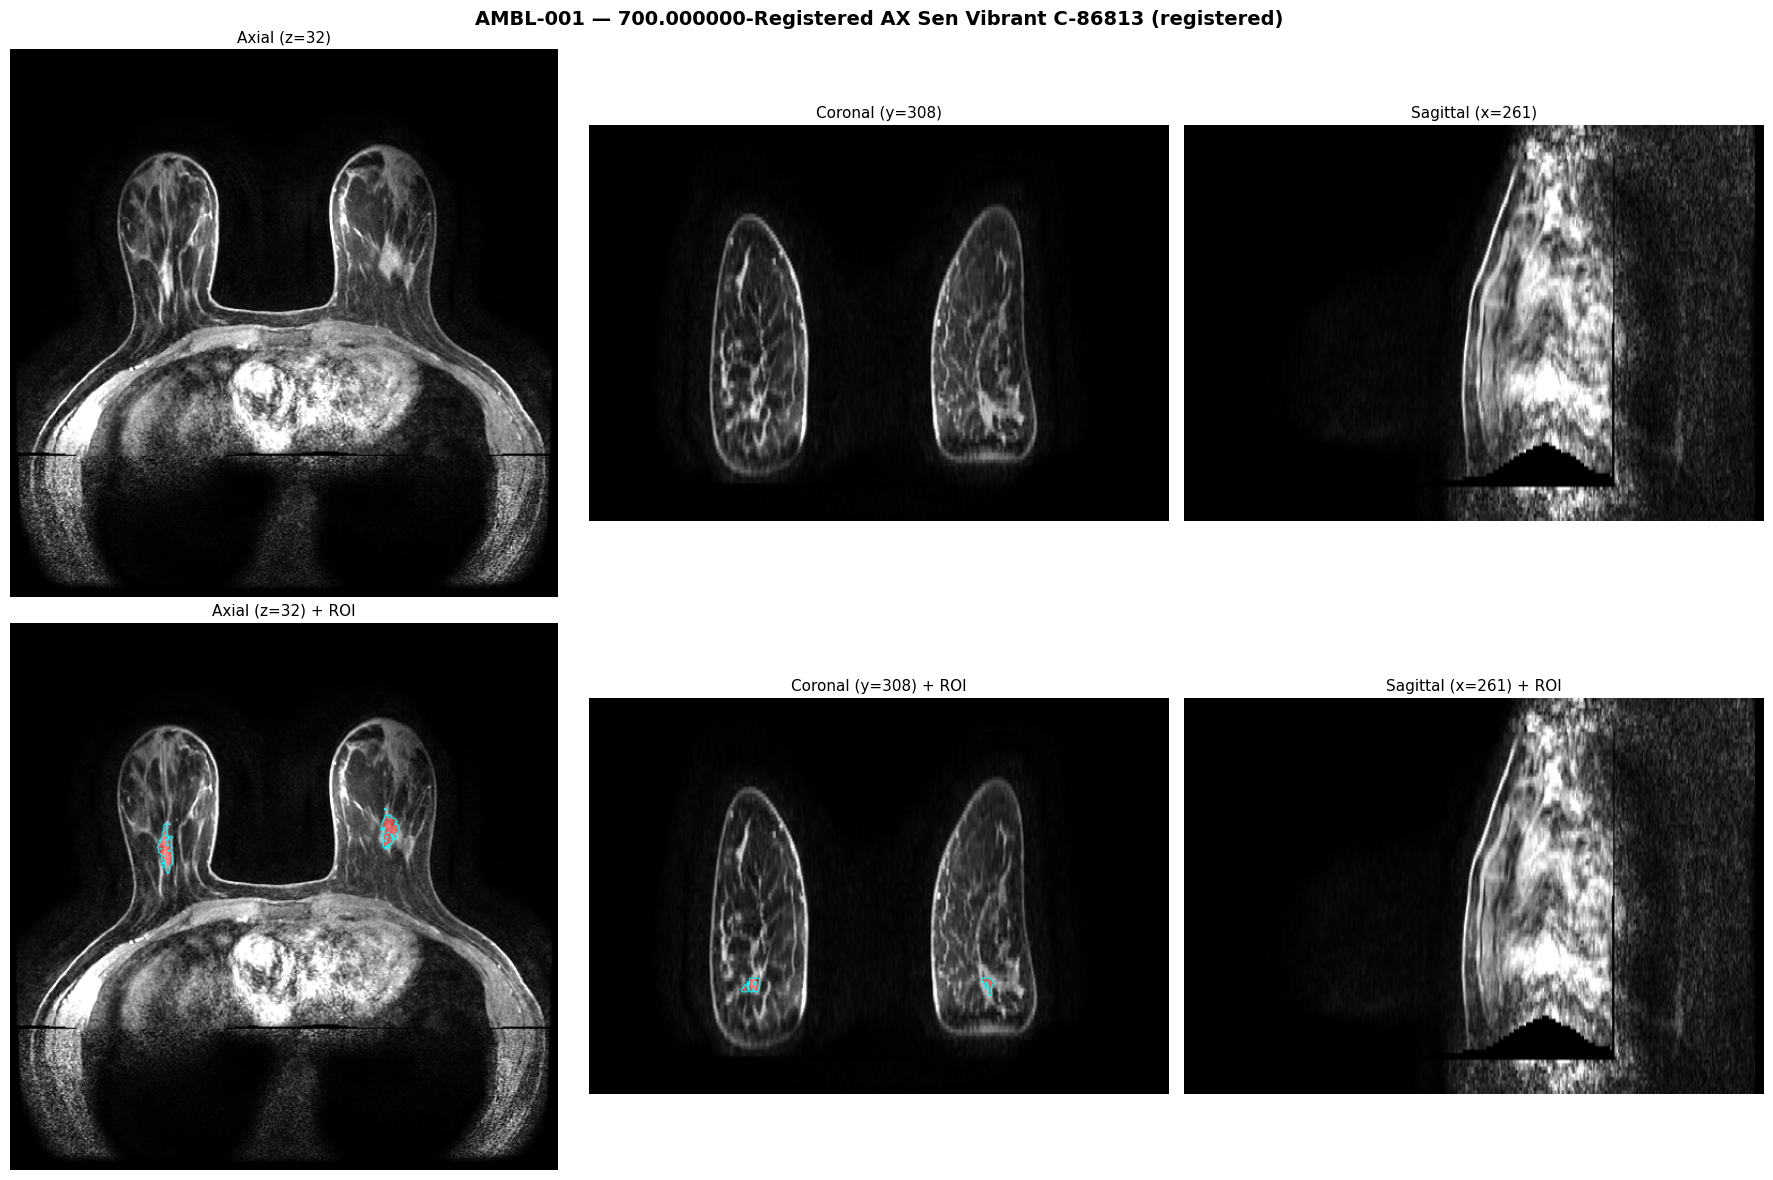

In [ ]:
# =============================================================================
# Verification - one patient, three views + ROI overlay (self-contained)
# =============================================================================

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
DICOM_FOLDER   = r"D:\Advanced-MRI-Breast-Lesions\DICOM Images\manifest-1713182663002\Advanced-MRI-Breast-Lesions"
PATIENT_ID     = "AMBL-001"
DISPLAY_SERIES = "registered"   # "registered" = pipeline input, "raw" = native series
Z_TOLERANCE    = 0.5            # mm
P_LOW, P_HIGH  = 1.0, 99.0      # contrast window percentiles (lower P_HIGH for more contrast)
EXCLUDE_AIR    = False          # True = also drop air for maximum contrast

# -----------------------------------------------------------------------------
# SERIES SELECTORS
# -----------------------------------------------------------------------------
def is_registered_ax_vibrant(name):
    n = name.upper()
    return ("REGISTERED" in n and "AX" in n and "VIBRAN" in n
            and "MULTIPHASE" not in n and "T2" not in n and "MASK" not in n)

def is_raw_ax_vibrant(name):
    n = name.upper()
    return ("AX" in n and "VIBRAN" in n and "REGISTERED" not in n
            and "MULTIPHASE" not in n and "TRAM" not in n and "MASK" not in n)

def _series_number(name):
    try:
        return float(name.split(".")[0])
    except ValueError:
        return float("inf")

def select_series_folder(patient_subfolder, mode="registered"):
    """mode = 'registered', 'raw', or 'auto' (registered, else raw)."""
    dirs = [d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))]
    reg = sorted([d for d in dirs if is_registered_ax_vibrant(d)], key=_series_number)
    raw = sorted([d for d in dirs if is_raw_ax_vibrant(d)],        key=_series_number)
    if mode in ("registered", "auto") and reg:
        return os.path.join(patient_subfolder, reg[0]), reg[0], "registered"
    if mode in ("raw", "auto") and raw:
        return os.path.join(patient_subfolder, raw[0]), raw[0], "raw"
    return None, None, None

# -----------------------------------------------------------------------------
# ORIENTATION + ASPECT (identical to the first STEP-1 cell)
# -----------------------------------------------------------------------------
def orient(x):
    """180 degree rotation, equals np.fliplr(np.flipud(x)). Applied to both image and mask."""
    return np.rot90(x, 2)

def safe_aspect(num, den):
    if den == 0 or not np.isfinite(num / den):
        return 1.0
    r = num / den
    return r if r > 0 else 1.0

# -----------------------------------------------------------------------------
# NORMALIZATION - window computed from body voxels (fixes washed-out registered)
# -----------------------------------------------------------------------------
def normalize_volume(vol, p_low=1.0, p_high=99.0, exclude_air=False):
    """
    Global percentile windowing, with the low/high bounds estimated from body
    voxels only. Registered series fill out-of-FOV regions with a constant value
    below the air background; that floor drags the first percentile down and the
    image turns foggy. Dropping the floor (and optionally air) restores crisp contrast.
    """
    v = np.nan_to_num(vol.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    vmin, vmax = float(v.min()), float(v.max())
    eps  = (vmax - vmin) * 1e-3
    body = v[v > vmin + eps]                         # drop the constant dark-fill plateau
    if exclude_air and body.size:
        thr   = 0.10 * np.percentile(body, 99.5)     # threshold to also drop air
        body2 = body[body > thr]
        if body2.size > 1000:
            body = body2
    if body.size < 100:
        body = v.ravel()
    lo, hi = np.percentile(body, p_low), np.percentile(body, p_high)
    if hi - lo < 1e-6:
        lo, hi = vmin, vmax
    return np.clip((v - lo) / (hi - lo + 1e-6), 0.0, 1.0)

# -----------------------------------------------------------------------------
# IMAGE VOLUME + PER-SLICE Z
# -----------------------------------------------------------------------------
def load_volume_with_z(series_folder, p_low=1.0, p_high=99.0, exclude_air=False):
    slices = []
    for f in os.listdir(series_folder):
        if not f.lower().endswith(".dcm"):
            continue
        try:
            ds  = pydicom.dcmread(os.path.join(series_folder, f))
            arr = ds.pixel_array.astype(np.float32)
            if arr.ndim == 3:                      # packed multi-frame safety
                arr = arr[arr.shape[0] // 2]
            z   = float(ds.ImagePositionPatient[2]) if hasattr(ds, "ImagePositionPatient") else 0.0
            rsp = float(ds.PixelSpacing[0]) if hasattr(ds, "PixelSpacing") else 1.0
            csp = float(ds.PixelSpacing[1]) if hasattr(ds, "PixelSpacing") else 1.0
            slices.append((z, arr, rsp, csp))
        except Exception:
            continue
    if not slices:
        raise RuntimeError("No readable DICOM files in series.")
    slices.sort(key=lambda s: s[0])
    zs  = np.array([s[0] for s in slices])
    vol = np.stack([s[1] for s in slices], axis=0)
    rsp, csp = slices[0][2], slices[0][3]
    z_sp = float(np.median(np.abs(np.diff(zs)))) if len(zs) > 1 else 1.0
    vol  = normalize_volume(vol, p_low, p_high, exclude_air)
    return vol, zs, (z_sp, rsp, csp)

# -----------------------------------------------------------------------------
# ROI: find SEG file + build a mask volume aligned to images by nearest Z
# -----------------------------------------------------------------------------
def find_roi_file(patient_subfolder):
    rois = [d for d in os.listdir(patient_subfolder)
            if os.path.isdir(os.path.join(patient_subfolder, d))
            and "ROI" in d.upper() and "TRAM" not in d.upper()]
    for d in rois:
        folder = os.path.join(patient_subfolder, d)
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(".dcm"):
                return os.path.join(folder, f), d
    return None, None

def load_seg_aligned(roi_file, image_zs, image_hw, z_tol=0.5):
    ds_seg  = pydicom.dcmread(roi_file)
    seg_arr = ds_seg.pixel_array.astype(np.uint8)
    if seg_arr.ndim == 2:
        seg_arr = seg_arr[None, ...]
    try:
        seg_zs = [float(fg.PlanePositionSequence[0].ImagePositionPatient[2])
                  for fg in ds_seg.PerFrameFunctionalGroupsSequence]
    except Exception:
        try:
            sg = ds_seg.SharedFunctionalGroupsSequence[0]
            z0 = float(sg.PlanePositionSequence[0].ImagePositionPatient[2])
            seg_zs = [z0] * seg_arr.shape[0]
        except Exception as e:
            raise RuntimeError(f"Could not read per-frame Z from SEG: {e}")
    seg_zs = np.array(seg_zs, dtype=float)

    z_to_mask = {}                                  # union frames sharing a Z (multi-lesion SEGs)
    for i, z in enumerate(seg_zs):
        key = round(float(z), 2)
        frame = seg_arr[i] > 0
        z_to_mask[key] = (z_to_mask[key] | frame) if key in z_to_mask else frame
    uniq_z = np.array(sorted(z_to_mask.keys()))

    H, W = int(image_hw[0]), int(image_hw[1])
    aligned, dists = np.zeros((len(image_zs), H, W), np.uint8), []
    for i, z in enumerate(image_zs):
        j = int(np.argmin(np.abs(uniq_z - z)))
        d = abs(uniq_z[j] - z)
        if d <= z_tol:
            m = z_to_mask[uniq_z[j]].astype(np.uint8)
            if m.shape != (H, W):
                try:
                    import cv2
                    m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
                except Exception:
                    continue
            aligned[i] = (m > 0).astype(np.uint8)
            dists.append(d)

    stats = dict(n_matched=int((aligned.reshape(len(aligned), -1).sum(1) > 0).sum()),
                 mean_dist=float(np.mean(dists)) if dists else None)
    return aligned, stats

# -----------------------------------------------------------------------------
# PLOT: top row = clean views, bottom row = same views + ROI overlay
# -----------------------------------------------------------------------------
def show_three_views_with_roi(volume, mask_vol, spacing, patient_id, series_name):
    z_sp, r_sp, c_sp = spacing
    Z, H, W = volume.shape

    if mask_vol is not None and mask_vol.sum() > 0:
        areas = mask_vol.reshape(Z, -1).sum(1)
        zc = int(np.argmax(areas))
        ys, xs = np.where(mask_vol[zc] > 0)
        yc, xc = int(ys.mean()), int(xs.mean())
    else:
        zc, yc, xc = Z // 2, H // 2, W // 2

    planes = [
        (orient(volume[zc, :, :]), None if mask_vol is None else orient(mask_vol[zc, :, :]),
         safe_aspect(r_sp, c_sp), f"Axial (z={zc})"),
        (orient(volume[:, yc, :]), None if mask_vol is None else orient(mask_vol[:, yc, :]),
         safe_aspect(z_sp, c_sp), f"Coronal (y={yc})"),
        (orient(volume[:, :, xc]), None if mask_vol is None else orient(mask_vol[:, :, xc]),
         safe_aspect(z_sp, r_sp), f"Sagittal (x={xc})"),
    ]

    has_mask = mask_vol is not None and mask_vol.sum() > 0
    nrows = 2 if has_mask else 1
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 6 * nrows))
    if nrows == 1:
        axes = axes[None, :]
    fig.suptitle(f"{patient_id} — {series_name}", fontsize=14, fontweight="bold")

    for col, (img, msk, asp, title) in enumerate(planes):
        axes[0, col].imshow(img, cmap="gray", aspect=asp)        # clean
        axes[0, col].set_title(title, fontsize=11)
        axes[0, col].axis("off")
        if has_mask:
            axes[1, col].imshow(img, cmap="gray", aspect=asp)    # + ROI
            if msk is not None and msk.sum() > 0:
                axes[1, col].imshow(np.ma.masked_where(msk == 0, msk),
                                    cmap="autumn", alpha=0.45, aspect=asp)
                axes[1, col].contour(msk, levels=[0.5], colors="cyan", linewidths=0.8)
            axes[1, col].set_title(f"{title} + ROI", fontsize=11)
            axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# RUN
# -----------------------------------------------------------------------------
p_path = os.path.join(DICOM_FOLDER, PATIENT_ID)
psub   = os.path.join(p_path, next(d for d in os.listdir(p_path)
                                   if os.path.isdir(os.path.join(p_path, d))))
series_folder, series_name, kind = select_series_folder(
    psub, mode="raw" if DISPLAY_SERIES == "raw" else "registered")

volume, image_zs, spacing = load_volume_with_z(
    series_folder, p_low=P_LOW, p_high=P_HIGH, exclude_air=EXCLUDE_AIR)
print(f"Patient {PATIENT_ID} · series '{series_name}' ({kind}) · volume {volume.shape}")
print(f"  display range after norm: [{volume.min():.3f}, {volume.max():.3f}]  "
      f"mean={volume.mean():.3f}  (mean well below ~0.3 = good, dark background)")

roi_file, _ = find_roi_file(psub)
mask_vol = None
if roi_file:
    mask_vol, st = load_seg_aligned(roi_file, image_zs, volume.shape[1:], z_tol=Z_TOLERANCE)
    print(f"  matched slices: {st['n_matched']}  mean ΔZ: {st['mean_dist']}")
else:
    print("  No ROI for this patient — showing image only.")

show_three_views_with_roi(volume, mask_vol, spacing, PATIENT_ID, f"{series_name} ({kind})")

### Slice-count overview per patient (Registered AX Sen Vibrant series)

In [ ]:
# =============================================================================
# Overview: slices per patient + hypothetical total after preprocessing
# (counts files in the selected series - no pixel data read)
# =============================================================================

rows, total, labeled_slices, n_labeled, n_skip = [], 0, 0, 0, 0
all_patients = sorted([d for d in os.listdir(DICOM_FOLDER)
                       if os.path.isdir(os.path.join(DICOM_FOLDER, d))])

for pid in all_patients:
    p_path = os.path.join(DICOM_FOLDER, pid)
    subs = [d for d in os.listdir(p_path) if os.path.isdir(os.path.join(p_path, d))]
    if not subs:
        n_skip += 1; rows.append((pid, 0, False, "no subfolder")); continue
    psub = os.path.join(p_path, subs[0])
    series_folder, sname, kind = select_series_folder(psub, mode="auto")
    if series_folder is None:
        n_skip += 1; rows.append((pid, 0, False, "no series")); continue
    n = sum(1 for f in os.listdir(series_folder) if f.lower().endswith(".dcm"))
    has_roi = find_roi_file(psub)[0] is not None
    rows.append((pid, n, has_roi, kind)); total += n
    if has_roi: labeled_slices += n; n_labeled += 1

print(f"{'Patient':<12}{'slices':>8}{'ROI':>6}  series")
for pid, n, roi, kind in rows[:8]:
    print(f"{pid:<12}{n:>8}{('yes' if roi else '-'):>6}  {kind}")
print("   ...")
for pid, n, roi, kind in rows[-4:]:
    print(f"{pid:<12}{n:>8}{('yes' if roi else '-'):>6}  {kind}")

mb_per_slice = (256*256*2 + 256*256*1) / 1e6      # float16 image + uint8 mask
print("\n" + "=" * 55)
print(f"Patients scanned           : {len(all_patients)}")
print(f"Patients with usable series : {len(all_patients) - n_skip}")
print(f"Patients with ROI mask      : {n_labeled}")
print(f"Total slices (upper bound)  : {total:,}")
print(f"   labeled slices           : {labeled_slices:,}")
print(f"   unlabeled slices         : {total - labeled_slices:,}")
print(f"Est. disk @256x256 f16+u8   : {total*mb_per_slice:,.0f} MB "
      f"(~{total*mb_per_slice/1024:.1f} GB)")
print("Note: this is the UPPER bound. DROP_AIR in preprocessing trims near-empty "
      "unlabeled slices, so the real total will be lower.")

Patient       slices   ROI  series
AMBL-001         116   yes  registered
AMBL-002         116     -  registered
AMBL-003         112   yes  registered
AMBL-004         116   yes  registered
AMBL-005         116   yes  registered
AMBL-006         116     -  registered
AMBL-007         116   yes  registered
AMBL-008         116   yes  registered
   ...
AMBL-629         116   yes  registered
AMBL-630           0     -  no series
AMBL-631         116   yes  registered
AMBL-632         116   yes  registered

Patients scanned           : 632
Patients with usable series : 613
Patients with ROI mask      : 94
Total slices (upper bound)  : 71,010
   labeled slices           : 10,882
   unlabeled slices         : 60,128
Est. disk @256x256 f16+u8   : 13,961 MB (~13.6 GB)
Note: this is the UPPER bound. DROP_AIR in preprocessing trims near-empty unlabeled slices, so the real total will be lower.
